# FinRAG Analyst
## AI-Powered Fundamental Stock Analysis Using Retrieval-Augmented Generation (RAG)

**Selected Company:** Microsoft Corporation  
**Ticker:** MSFT  
**Project Type:** Generative AI Capstone Project  

### Project Objective

The objective of this project is to develop an AI-powered fundamental stock analysis system using Retrieval-Augmented Generation (RAG).

The system collects financial information for Microsoft Corporation from Yahoo Finance, transforms the financial data into a structured knowledge base, generates vector embeddings, and stores them in a FAISS vector database.

When a user asks a financial question, the system retrieves the most relevant financial information from the vector database and provides the retrieved context to Google Gemini to generate a grounded fundamental analysis.

The project focuses on financial performance, profitability, revenue growth, EPS, assets and liabilities, debt and cash position, cash flows, financial ratios, historical performance, financial strengths, and potential risks.

In [97]:
%pip install -q yfinance pandas numpy matplotlib seaborn \
    faiss-cpu sentence-transformers google-genai python-dotenv

In [98]:
import faiss
import numpy as np

print("FAISS version:", faiss.__version__)

test_vectors = np.random.random(
    (5, 384)
).astype("float32")

test_index = faiss.IndexFlatIP(384)
test_index.add(test_vectors)

print("Vectors stored:", test_index.ntotal)

assert test_index.ntotal == 5

print("✓ FAISS is operational.")

FAISS version: 1.15.1
Vectors stored: 5
✓ FAISS is operational.


In [99]:
import os
import sys
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

print("Python version:", sys.version.split()[0])
print("Pandas version:", pd.__version__)
print("yfinance version:", yf.__version__)

Python version: 3.13.16
Pandas version: 2.2.3
yfinance version: 0.2.66


In [100]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

TICKER = "MSFT"
COMPANY_NAME = "Microsoft Corporation"

BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "data"
VECTOR_DIR = BASE_DIR / "vector_store"
OUTPUT_DIR = BASE_DIR / "outputs"

for folder in [DATA_DIR, VECTOR_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project Configuration")
print("-" * 60)
print(f"Company      : {COMPANY_NAME}")
print(f"Ticker       : {TICKER}")
print(f"Project path : {BASE_DIR}")
print(f"Data folder  : {DATA_DIR}")
print(f"Vector store : {VECTOR_DIR}")
print(f"Outputs      : {OUTPUT_DIR}")

Project Configuration
------------------------------------------------------------
Company      : Microsoft Corporation
Ticker       : MSFT
Project path : /content
Data folder  : /content/data
Vector store : /content/vector_store
Outputs      : /content/outputs


In [101]:
# Create Yahoo Finance ticker object

stock = yf.Ticker(TICKER)

print(f"Yahoo Finance object created successfully for {TICKER}.")

Yahoo Finance object created successfully for MSFT.


In [102]:
# ============================================================
# COMPANY INFORMATION
# ============================================================

company_info = stock.info

print("Company Information")
print("=" * 70)

print(f"Company Name       : {company_info.get('longName', 'N/A')}")
print(f"Ticker             : {TICKER}")
print(f"Sector             : {company_info.get('sector', 'N/A')}")
print(f"Industry           : {company_info.get('industry', 'N/A')}")
print(f"Country            : {company_info.get('country', 'N/A')}")
print(f"Website            : {company_info.get('website', 'N/A')}")
print(f"Employees          : {company_info.get('fullTimeEmployees', 'N/A')}")
print(f"Market Cap         : {company_info.get('marketCap', 'N/A')}")
print(f"Current Price      : {company_info.get('currentPrice', 'N/A')}")
print(f"Currency           : {company_info.get('currency', 'N/A')}")

Company Information
Company Name       : Microsoft Corporation
Ticker             : MSFT
Sector             : Technology
Industry           : Software - Infrastructure
Country            : United States
Website            : https://www.microsoft.com
Employees          : 223000
Market Cap         : 3930341244928
Current Price      : 529.3
Currency           : USD


In [103]:
company_profile = {
    "ticker": TICKER,
    "company_name": company_info.get("longName"),
    "sector": company_info.get("sector"),
    "industry": company_info.get("industry"),
    "country": company_info.get("country"),
    "website": company_info.get("website"),
    "employees": company_info.get("fullTimeEmployees"),
    "currency": company_info.get("currency"),
    "market_cap": company_info.get("marketCap"),
    "current_price": company_info.get("currentPrice"),
    "previous_close": company_info.get("previousClose"),
    "fifty_two_week_high": company_info.get("fiftyTwoWeekHigh"),
    "fifty_two_week_low": company_info.get("fiftyTwoWeekLow"),
    "trailing_pe": company_info.get("trailingPE"),
    "forward_pe": company_info.get("forwardPE"),
    "price_to_book": company_info.get("priceToBook"),
    "trailing_eps": company_info.get("trailingEps"),
    "forward_eps": company_info.get("forwardEps"),
    "dividend_yield": company_info.get("dividendYield"),
    "beta": company_info.get("beta"),
    "business_summary": company_info.get("longBusinessSummary")
}

profile_df = pd.DataFrame(
    company_profile.items(),
    columns=["Metric", "Value"]
)

display(profile_df)

,Metric,Value
0,ticker,MSFT
1,company_name,Microsoft Corporation
2,sector,Technology
3,industry,Software - Infrastructure
4,country,United States
5,website,https://www.microsoft.com
6,employees,223000
7,currency,USD
8,market_cap,3930341244928
9,current_price,529.30


In [104]:
# ============================================================
# FINANCIAL STATEMENTS
# ============================================================

income_statement = stock.financials.copy()
balance_sheet = stock.balance_sheet.copy()
cash_flow = stock.cashflow.copy()

print("Financial Statements Retrieved")
print("=" * 60)

print(
    f"Income Statement : "
    f"{income_statement.shape[0]} metrics × "
    f"{income_statement.shape[1]} periods"
)

print(
    f"Balance Sheet    : "
    f"{balance_sheet.shape[0]} metrics × "
    f"{balance_sheet.shape[1]} periods"
)

print(
    f"Cash Flow        : "
    f"{cash_flow.shape[0]} metrics × "
    f"{cash_flow.shape[1]} periods"
)

Financial Statements Retrieved
Income Statement : 47 metrics × 4 periods
Balance Sheet    : 79 metrics × 5 periods
Cash Flow        : 59 metrics × 5 periods


In [105]:
print("MICROSOFT — INCOME STATEMENT")
print("=" * 80)

display(income_statement)

MICROSOFT — INCOME STATEMENT


,2026-06-30,2025-06-30,2024-06-30,2023-06-30
Tax Effect Of Unusual Items,"1,110,650,000.00","-77,217,840.76","-100,089,983.02","-2,850,000.00"
Tax Rate For Calcs,0.19,0.18,0.18,0.19
Normalized EBITDA,"201,794,000,000.00","155,883,000,000.00","132,229,000,000.00","105,155,000,000.00"
Total Unusual Items,"5,725,000,000.00","-438,000,000.00","-549,000,000.00","-15,000,000.00"
Total Unusual Items Excluding Goodwill,"5,725,000,000.00","-438,000,000.00","-549,000,000.00","-15,000,000.00"
Net Income From Continuing Operation Net Minority Interest,"133,749,000,000.00","101,832,000,000.00","88,136,000,000.00","72,361,000,000.00"
Reconciled Depreciation,"38,534,000,000.00","29,433,000,000.00","20,958,000,000.00","13,861,000,000.00"
Reconciled Cost Of Revenue,"106,374,000,000.00","87,831,000,000.00","74,114,000,000.00","65,863,000,000.00"
EBITDA,"207,519,000,000.00","155,445,000,000.00","131,680,000,000.00","105,140,000,000.00"
EBIT,"168,985,000,000.00","126,012,000,000.00","110,722,000,000.00","91,279,000,000.00"


In [106]:
print("MICROSOFT — BALANCE SHEET")
print("=" * 80)

display(balance_sheet)

MICROSOFT — BALANCE SHEET


,2026-06-30,2025-06-30,2024-06-30,2023-06-30,2022-06-30
Ordinary Shares Number,"7,427,000,000.00","7,434,158,655.00","7,434,138,859.00","7,432,000,000.00",NaN
Share Issued,"7,427,000,000.00","7,434,158,655.00","7,434,138,859.00","7,432,000,000.00",NaN
Net Debt,"19,359,000,000.00","12,909,000,000.00","33,315,000,000.00","12,533,000,000.00",NaN
Total Debt,"56,826,000,000.00","60,588,000,000.00","67,127,000,000.00","59,965,000,000.00",NaN
Tangible Book Value,"304,127,000,000.00","201,366,000,000.00","121,660,000,000.00","128,971,000,000.00",NaN
Invested Capital,"482,681,000,000.00","386,630,000,000.00","320,107,000,000.00","253,460,000,000.00",NaN
Working Capital,"38,885,000,000.00","49,913,000,000.00","34,448,000,000.00","80,108,000,000.00",NaN
Net Tangible Assets,"304,127,000,000.00","201,366,000,000.00","121,660,000,000.00","128,971,000,000.00",NaN
Capital Lease Obligations,"16,532,000,000.00","17,437,000,000.00","15,497,000,000.00","12,728,000,000.00",NaN
Common Stock Equity,"442,387,000,000.00","343,479,000,000.00","268,477,000,000.00","206,223,000,000.00",NaN


In [107]:
print("MICROSOFT — CASH FLOW STATEMENT")
print("=" * 80)

display(cash_flow)

MICROSOFT — CASH FLOW STATEMENT


,2026-06-30,2025-06-30,2024-06-30,2023-06-30,2022-06-30
Free Cash Flow,"66,987,000,000.00","71,611,000,000.00","74,071,000,000.00","59,475,000,000.00",NaN
Repurchase Of Capital Stock,"-22,271,000,000.00","-18,420,000,000.00","-17,254,000,000.00","-22,245,000,000.00",NaN
Repayment Of Debt,"-3,000,000,000.00","-3,216,000,000.00","-29,070,000,000.00","-2,750,000,000.00",NaN
Issuance Of Debt,0.00,0.00,"24,395,000,000.00",0.00,NaN
Issuance Of Capital Stock,"2,009,000,000.00","2,056,000,000.00","2,002,000,000.00","1,866,000,000.00",NaN
Capital Expenditure,"-115,948,000,000.00","-64,551,000,000.00","-44,477,000,000.00","-28,107,000,000.00",NaN
End Cash Position,"20,935,000,000.00","30,242,000,000.00","18,315,000,000.00","34,704,000,000.00",NaN
Beginning Cash Position,"30,242,000,000.00","18,315,000,000.00","34,704,000,000.00","13,931,000,000.00",NaN
Effect Of Exchange Rate Changes,"-196,000,000.00","63,000,000.00","-210,000,000.00","-194,000,000.00",NaN
Changes In Cash,"-9,111,000,000.00","11,864,000,000.00","-16,179,000,000.00","20,967,000,000.00",NaN


In [108]:
# ============================================================
# HISTORICAL MARKET DATA
# ============================================================

price_history = stock.history(period="5y")

print("Historical Price Data")
print("=" * 60)

print(f"Records    : {len(price_history):,}")

if not price_history.empty:
    print(f"Start Date : {price_history.index.min().date()}")
    print(f"End Date   : {price_history.index.max().date()}")

display(price_history.head())

Historical Price Data
Records    : 1,254
Start Date : 2021-10-07
End Date   : 2026-10-06


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-10-07 00:00:00-04:00,283.29,284.69,282.08,282.98,20430500,0.00,0.00
2021-10-08 00:00:00-04:00,284.29,284.69,281.93,282.98,17685700,0.00,0.00
2021-10-11 00:00:00-04:00,281.12,285.97,280.96,282.38,19298600,0.00,0.00
2021-10-12 00:00:00-04:00,283.45,283.54,280.58,281.08,17974100,0.00,0.00
2021-10-13 00:00:00-04:00,283.03,285.31,281.67,284.38,23416300,0.00,0.00


In [109]:
display(price_history.tail())

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-30 00:00:00-04:00,511.61,519.83,510.31,512.90,27223300,0.00,0.00
2026-10-01 00:00:00-04:00,519.88,522.85,512.17,512.80,19731900,0.00,0.00
2026-10-02 00:00:00-04:00,519.39,522.50,513.66,517.53,17822300,0.00,0.00
2026-10-05 00:00:00-04:00,521.62,532.35,521.47,525.18,26604800,0.00,0.00
2026-10-06 00:00:00-04:00,531.68,535.69,528.78,529.30,21092600,0.00,0.00


In [110]:
# ============================================================
# DATA VALIDATION
# ============================================================

validation_results = {
    "Company Information": bool(company_info),
    "Income Statement": not income_statement.empty,
    "Balance Sheet": not balance_sheet.empty,
    "Cash Flow Statement": not cash_flow.empty,
    "Historical Prices": not price_history.empty
}

validation_df = pd.DataFrame(
    validation_results.items(),
    columns=["Data Source", "Available"]
)

display(validation_df)

if all(validation_results.values()):
    print("\n✓ All required financial datasets were retrieved successfully.")
else:
    print("\n⚠ Some financial datasets are missing. Review before continuing.")

,Data Source,Available
0,Company Information,True
1,Income Statement,True
2,Balance Sheet,True
3,Cash Flow Statement,True
4,Historical Prices,True



✓ All required financial datasets were retrieved successfully.


In [111]:
# ============================================================
# SAVE RAW FINANCIAL DATA
# ============================================================

income_statement.to_csv(
    DATA_DIR / "msft_income_statement.csv"
)

balance_sheet.to_csv(
    DATA_DIR / "msft_balance_sheet.csv"
)

cash_flow.to_csv(
    DATA_DIR / "msft_cash_flow.csv"
)

price_history.to_csv(
    DATA_DIR / "msft_price_history.csv"
)

profile_df.to_csv(
    DATA_DIR / "msft_company_profile.csv",
    index=False
)

print("Financial datasets saved successfully:\n")

for file in sorted(DATA_DIR.iterdir()):
    print("✓", file.name)

Financial datasets saved successfully:

✓ msft_balance_sheet.csv
✓ msft_cash_flow.csv
✓ msft_company_profile.csv
✓ msft_data_quality_report.csv
✓ msft_financial_chunks.json
✓ msft_financial_knowledge_base.json
✓ msft_financial_summary.csv
✓ msft_financial_summary_readable.csv
✓ msft_fundamental_trends.csv
✓ msft_income_statement.csv
✓ msft_price_analysis.csv
✓ msft_price_history.csv


# Stage 2 — Financial Data Engineering

This stage transforms the raw financial statements retrieved from Yahoo Finance into structured fundamental indicators suitable for financial analysis and Retrieval-Augmented Generation (RAG).

The analysis covers:

- Revenue and revenue growth
- Gross, operating and net profitability
- Earnings per share (EPS)
- Assets, liabilities and shareholders' equity
- Cash and debt position
- Operating cash flow and free cash flow
- Key financial ratios
- Historical stock-price performance

The engineered financial metrics will later be converted into structured knowledge documents for embedding and storage in the FAISS vector database.

In [112]:
# ============================================================
# STAGE 2 — FINANCIAL DATA ENGINEERING
# ============================================================

print("INCOME STATEMENT FIELDS")
print("=" * 70)

for item in income_statement.index:
    print(item)

print("\n" + "=" * 70)
print("BALANCE SHEET FIELDS")
print("=" * 70)

for item in balance_sheet.index:
    print(item)

print("\n" + "=" * 70)
print("CASH FLOW FIELDS")
print("=" * 70)

for item in cash_flow.index:
    print(item)

INCOME STATEMENT FIELDS
Tax Effect Of Unusual Items
Tax Rate For Calcs
Normalized EBITDA
Total Unusual Items
Total Unusual Items Excluding Goodwill
Net Income From Continuing Operation Net Minority Interest
Reconciled Depreciation
Reconciled Cost Of Revenue
EBITDA
EBIT
Net Interest Income
Interest Expense
Interest Income
Normalized Income
Net Income From Continuing And Discontinued Operation
Total Expenses
Total Operating Income As Reported
Diluted Average Shares
Basic Average Shares
Diluted EPS
Basic EPS
Diluted NI Availto Com Stockholders
Net Income Common Stockholders
Net Income
Net Income Including Noncontrolling Interests
Net Income Continuous Operations
Tax Provision
Pretax Income
Other Income Expense
Other Non Operating Income Expenses
Special Income Charges
Write Off
Gain On Sale Of Security
Net Non Operating Interest Income Expense
Interest Expense Non Operating
Interest Income Non Operating
Operating Income
Operating Expense
Research And Development
Selling General And Admini

In [113]:
def get_financial_metric(statement, possible_names):
    """
    Retrieve a financial metric using one or more possible
    Yahoo Finance row names.

    Returns a Series indexed by reporting date.
    """

    for name in possible_names:

        if name in statement.index:

            result = statement.loc[name].copy()

            result = pd.to_numeric(
                result,
                errors="coerce"
            )

            return result

    return pd.Series(
        dtype="float64"
    )

In [114]:
# ============================================================
# INCOME STATEMENT METRICS
# ============================================================

revenue = get_financial_metric(
    income_statement,
    ["Total Revenue", "Operating Revenue"]
)

gross_profit = get_financial_metric(
    income_statement,
    ["Gross Profit"]
)

operating_income = get_financial_metric(
    income_statement,
    ["Operating Income"]
)

net_income = get_financial_metric(
    income_statement,
    [
        "Net Income",
        "Net Income Common Stockholders"
    ]
)

basic_eps = get_financial_metric(
    income_statement,
    ["Basic EPS"]
)

diluted_eps = get_financial_metric(
    income_statement,
    ["Diluted EPS"]
)

print("Metrics extracted:")
print("Revenue          :", not revenue.empty)
print("Gross Profit     :", not gross_profit.empty)
print("Operating Income :", not operating_income.empty)
print("Net Income       :", not net_income.empty)
print("Basic EPS        :", not basic_eps.empty)
print("Diluted EPS      :", not diluted_eps.empty)

Metrics extracted:
Revenue          : True
Gross Profit     : True
Operating Income : True
Net Income       : True
Basic EPS        : True
Diluted EPS      : True


In [115]:
# ============================================================
# BALANCE SHEET METRICS
# ============================================================

total_assets = get_financial_metric(
    balance_sheet,
    ["Total Assets"]
)

total_liabilities = get_financial_metric(
    balance_sheet,
    [
        "Total Liabilities Net Minority Interest",
        "Total Liabilities"
    ]
)

stockholders_equity = get_financial_metric(
    balance_sheet,
    [
        "Stockholders Equity",
        "Total Equity Gross Minority Interest"
    ]
)

cash = get_financial_metric(
    balance_sheet,
    [
        "Cash Cash Equivalents And Short Term Investments",
        "Cash And Cash Equivalents",
        "Cash Financial"
    ]
)

total_debt = get_financial_metric(
    balance_sheet,
    ["Total Debt"]
)

current_assets = get_financial_metric(
    balance_sheet,
    ["Current Assets", "Total Current Assets"]
)

current_liabilities = get_financial_metric(
    balance_sheet,
    ["Current Liabilities", "Total Current Liabilities"]
)

print("Balance Sheet Metrics")
print("=" * 60)

print("Total Assets        :", not total_assets.empty)
print("Total Liabilities   :", not total_liabilities.empty)
print("Stockholders Equity :", not stockholders_equity.empty)
print("Cash                :", not cash.empty)
print("Total Debt          :", not total_debt.empty)
print("Current Assets      :", not current_assets.empty)
print("Current Liabilities :", not current_liabilities.empty)

Balance Sheet Metrics
Total Assets        : True
Total Liabilities   : True
Stockholders Equity : True
Cash                : True
Total Debt          : True
Current Assets      : True
Current Liabilities : True


In [116]:
# ============================================================
# CASH FLOW METRICS
# ============================================================

operating_cash_flow = get_financial_metric(
    cash_flow,
    [
        "Operating Cash Flow",
        "Total Cash From Operating Activities"
    ]
)

capital_expenditure = get_financial_metric(
    cash_flow,
    [
        "Capital Expenditure",
        "Capital Expenditures"
    ]
)

free_cash_flow = get_financial_metric(
    cash_flow,
    ["Free Cash Flow"]
)

print("Cash Flow Metrics")
print("=" * 60)

print(
    "Operating Cash Flow :",
    not operating_cash_flow.empty
)

print(
    "Capital Expenditure :",
    not capital_expenditure.empty
)

print(
    "Free Cash Flow      :",
    not free_cash_flow.empty
)

Cash Flow Metrics
Operating Cash Flow : True
Capital Expenditure : True
Free Cash Flow      : True


In [117]:
# ============================================================
# BUILD ANNUAL FINANCIAL SUMMARY
# ============================================================

financial_summary = pd.DataFrame()

metrics = {
    "Revenue": revenue,
    "Gross Profit": gross_profit,
    "Operating Income": operating_income,
    "Net Income": net_income,
    "Basic EPS": basic_eps,
    "Diluted EPS": diluted_eps,
    "Total Assets": total_assets,
    "Total Liabilities": total_liabilities,
    "Stockholders Equity": stockholders_equity,
    "Cash": cash,
    "Total Debt": total_debt,
    "Current Assets": current_assets,
    "Current Liabilities": current_liabilities,
    "Operating Cash Flow": operating_cash_flow,
    "Capital Expenditure": capital_expenditure,
    "Free Cash Flow": free_cash_flow
}

for metric_name, series in metrics.items():

    if not series.empty:

        financial_summary[metric_name] = series

# Sort oldest → newest
financial_summary = financial_summary.sort_index()

# Remove rows where everything is missing
financial_summary = financial_summary.dropna(
    how="all"
)

financial_summary.index.name = "Fiscal Year"

display(financial_summary)

,Revenue,Gross Profit,Operating Income,Net Income,Basic EPS,Diluted EPS,Total Assets,Total Liabilities,Stockholders Equity,Cash,Total Debt,Current Assets,Current Liabilities,Operating Cash Flow,Capital Expenditure,Free Cash Flow
Fiscal Year,,,,,,,,,,,,,,,,
2023-06-30,"211,915,000,000.00","146,052,000,000.00","88,523,000,000.00","72,361,000,000.00",9.72,9.68,"411,976,000,000.00","205,753,000,000.00","206,223,000,000.00","111,256,000,000.00","59,965,000,000.00","184,257,000,000.00","104,149,000,000.00","87,582,000,000.00","-28,107,000,000.00","59,475,000,000.00"
2024-06-30,"245,122,000,000.00","171,008,000,000.00","109,433,000,000.00","88,136,000,000.00",11.86,11.80,"512,163,000,000.00","243,686,000,000.00","268,477,000,000.00","75,531,000,000.00","67,127,000,000.00","159,734,000,000.00","125,286,000,000.00","118,548,000,000.00","-44,477,000,000.00","74,071,000,000.00"
2025-06-30,"281,724,000,000.00","193,893,000,000.00","128,528,000,000.00","101,832,000,000.00",13.70,13.64,"619,003,000,000.00","275,524,000,000.00","343,479,000,000.00","94,555,000,000.00","60,588,000,000.00","191,131,000,000.00","141,218,000,000.00","136,162,000,000.00","-64,551,000,000.00","71,611,000,000.00"
2026-06-30,"331,839,000,000.00","225,465,000,000.00","155,237,000,000.00","133,749,000,000.00",18.00,17.95,"758,376,000,000.00","315,989,000,000.00","442,387,000,000.00","76,651,000,000.00","56,826,000,000.00","207,710,000,000.00","168,825,000,000.00","182,935,000,000.00","-115,948,000,000.00","66,987,000,000.00"


In [118]:
financial_summary["Revenue Growth %"] = (
    financial_summary["Revenue"]
    .pct_change()
    .mul(100)
)

display(
    financial_summary[
        [
            "Revenue",
            "Revenue Growth %"
        ]
    ]
)

,Revenue,Revenue Growth %
Fiscal Year,,
2023-06-30,"211,915,000,000.00",NaN
2024-06-30,"245,122,000,000.00",15.67
2025-06-30,"281,724,000,000.00",14.93
2026-06-30,"331,839,000,000.00",17.79


In [119]:
# ============================================================
# PROFITABILITY RATIOS
# ============================================================

financial_summary["Gross Margin %"] = (
    financial_summary["Gross Profit"]
    / financial_summary["Revenue"]
    * 100
)

financial_summary["Operating Margin %"] = (
    financial_summary["Operating Income"]
    / financial_summary["Revenue"]
    * 100
)

financial_summary["Net Profit Margin %"] = (
    financial_summary["Net Income"]
    / financial_summary["Revenue"]
    * 100
)

display(
    financial_summary[
        [
            "Revenue",
            "Gross Margin %",
            "Operating Margin %",
            "Net Profit Margin %"
        ]
    ].round(2)
)

,Revenue,Gross Margin %,Operating Margin %,Net Profit Margin %
Fiscal Year,,,,
2023-06-30,"211,915,000,000.00",68.92,41.77,34.15
2024-06-30,"245,122,000,000.00",69.76,44.64,35.96
2025-06-30,"281,724,000,000.00",68.82,45.62,36.15
2026-06-30,"331,839,000,000.00",67.94,46.78,40.31


In [120]:
financial_summary["Diluted EPS Growth %"] = (
    financial_summary["Diluted EPS"]
    .pct_change()
    .mul(100)
)

display(
    financial_summary[
        [
            "Diluted EPS",
            "Diluted EPS Growth %"
        ]
    ].round(2)
)

,Diluted EPS,Diluted EPS Growth %
Fiscal Year,,
2023-06-30,9.68,NaN
2024-06-30,11.80,21.90
2025-06-30,13.64,15.59
2026-06-30,17.95,31.60


In [121]:
# ============================================================
# BALANCE SHEET RATIOS
# ============================================================

financial_summary["Debt to Equity"] = (
    financial_summary["Total Debt"]
    / financial_summary["Stockholders Equity"]
)

financial_summary["Debt to Assets"] = (
    financial_summary["Total Debt"]
    / financial_summary["Total Assets"]
)

financial_summary["Current Ratio"] = (
    financial_summary["Current Assets"]
    / financial_summary["Current Liabilities"]
)

financial_summary["Net Cash Position"] = (
    financial_summary["Cash"]
    - financial_summary["Total Debt"]
)

display(
    financial_summary[
        [
            "Total Assets",
            "Total Liabilities",
            "Cash",
            "Total Debt",
            "Net Cash Position",
            "Debt to Equity",
            "Current Ratio"
        ]
    ].round(2)
)

,Total Assets,Total Liabilities,Cash,Total Debt,Net Cash Position,Debt to Equity,Current Ratio
Fiscal Year,,,,,,,
2023-06-30,"411,976,000,000.00","205,753,000,000.00","111,256,000,000.00","59,965,000,000.00","51,291,000,000.00",0.29,1.77
2024-06-30,"512,163,000,000.00","243,686,000,000.00","75,531,000,000.00","67,127,000,000.00","8,404,000,000.00",0.25,1.27
2025-06-30,"619,003,000,000.00","275,524,000,000.00","94,555,000,000.00","60,588,000,000.00","33,967,000,000.00",0.18,1.35
2026-06-30,"758,376,000,000.00","315,989,000,000.00","76,651,000,000.00","56,826,000,000.00","19,825,000,000.00",0.13,1.23


In [122]:
average_assets = (
    financial_summary["Total Assets"]
    + financial_summary["Total Assets"].shift(1)
) / 2

average_equity = (
    financial_summary["Stockholders Equity"]
    + financial_summary["Stockholders Equity"].shift(1)
) / 2


financial_summary["ROA %"] = (
    financial_summary["Net Income"]
    / average_assets
    * 100
)

financial_summary["ROE %"] = (
    financial_summary["Net Income"]
    / average_equity
    * 100
)

display(
    financial_summary[
        [
            "Net Income",
            "ROA %",
            "ROE %"
        ]
    ].round(2)
)

,Net Income,ROA %,ROE %
Fiscal Year,,,
2023-06-30,"72,361,000,000.00",NaN,NaN
2024-06-30,"88,136,000,000.00",19.07,37.13
2025-06-30,"101,832,000,000.00",18.00,33.28
2026-06-30,"133,749,000,000.00",19.42,34.04


In [123]:
# ============================================================
# CASH FLOW ANALYSIS
# ============================================================

financial_summary["OCF Margin %"] = (
    financial_summary["Operating Cash Flow"]
    / financial_summary["Revenue"]
    * 100
)

financial_summary["FCF Margin %"] = (
    financial_summary["Free Cash Flow"]
    / financial_summary["Revenue"]
    * 100
)

financial_summary["Cash Conversion"] = (
    financial_summary["Operating Cash Flow"]
    / financial_summary["Net Income"]
)

display(
    financial_summary[
        [
            "Operating Cash Flow",
            "Free Cash Flow",
            "OCF Margin %",
            "FCF Margin %",
            "Cash Conversion"
        ]
    ].round(2)
)

,Operating Cash Flow,Free Cash Flow,OCF Margin %,FCF Margin %,Cash Conversion
Fiscal Year,,,,,
2023-06-30,"87,582,000,000.00","59,475,000,000.00",41.33,28.07,1.21
2024-06-30,"118,548,000,000.00","74,071,000,000.00",48.36,30.22,1.35
2025-06-30,"136,162,000,000.00","71,611,000,000.00",48.33,25.42,1.34
2026-06-30,"182,935,000,000.00","66,987,000,000.00",55.13,20.19,1.37


In [124]:
financial_summary_readable = financial_summary.copy()

currency_columns = [
    "Revenue",
    "Gross Profit",
    "Operating Income",
    "Net Income",
    "Total Assets",
    "Total Liabilities",
    "Stockholders Equity",
    "Cash",
    "Total Debt",
    "Current Assets",
    "Current Liabilities",
    "Operating Cash Flow",
    "Capital Expenditure",
    "Free Cash Flow",
    "Net Cash Position"
]

for column in currency_columns:

    if column in financial_summary_readable.columns:

        financial_summary_readable[column] = (
            financial_summary_readable[column]
            / 1_000_000_000
        )

display(
    financial_summary_readable.round(2)
)

,Revenue,Gross Profit,Operating Income,Net Income,Basic EPS,Diluted EPS,Total Assets,Total Liabilities,Stockholders Equity,Cash,Total Debt,Current Assets,Current Liabilities,Operating Cash Flow,Capital Expenditure,Free Cash Flow,Revenue Growth %,Gross Margin %,Operating Margin %,Net Profit Margin %,Diluted EPS Growth %,Debt to Equity,Debt to Assets,Current Ratio,Net Cash Position,ROA %,ROE %,OCF Margin %,FCF Margin %,Cash Conversion
Fiscal Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-06-30,211.92,146.05,88.52,72.36,9.72,9.68,411.98,205.75,206.22,111.26,59.96,184.26,104.15,87.58,-28.11,59.48,NaN,68.92,41.77,34.15,NaN,0.29,0.15,1.77,51.29,NaN,NaN,41.33,28.07,1.21
2024-06-30,245.12,171.01,109.43,88.14,11.86,11.80,512.16,243.69,268.48,75.53,67.13,159.73,125.29,118.55,-44.48,74.07,15.67,69.76,44.64,35.96,21.90,0.25,0.13,1.27,8.40,19.07,37.13,48.36,30.22,1.35
2025-06-30,281.72,193.89,128.53,101.83,13.70,13.64,619.00,275.52,343.48,94.56,60.59,191.13,141.22,136.16,-64.55,71.61,14.93,68.82,45.62,36.15,15.59,0.18,0.10,1.35,33.97,18.00,33.28,48.33,25.42,1.34
2026-06-30,331.84,225.46,155.24,133.75,18.00,17.95,758.38,315.99,442.39,76.65,56.83,207.71,168.82,182.94,-115.95,66.99,17.79,67.94,46.78,40.31,31.60,0.13,0.07,1.23,19.82,19.42,34.04,55.13,20.19,1.37


In [125]:
# ============================================================
# HISTORICAL STOCK PERFORMANCE
# ============================================================

prices = price_history.copy()

prices["Daily Return"] = (
    prices["Close"]
    .pct_change()
)

start_price = prices["Close"].iloc[0]
end_price = prices["Close"].iloc[-1]

total_return = (
    (end_price / start_price) - 1
) * 100

years = (
    prices.index[-1] -
    prices.index[0]
).days / 365.25

annualized_return = (
    (end_price / start_price) ** (1 / years)
    - 1
) * 100

annualized_volatility = (
    prices["Daily Return"].std()
    * np.sqrt(252)
    * 100
)

running_max = prices["Close"].cummax()

drawdown = (
    prices["Close"] / running_max
) - 1

max_drawdown = (
    drawdown.min()
    * 100
)

print("MICROSOFT — HISTORICAL STOCK PERFORMANCE")
print("=" * 65)

print(f"Period                 : {years:.2f} years")
print(f"Starting Price         : ${start_price:,.2f}")
print(f"Ending Price           : ${end_price:,.2f}")
print(f"Total Price Return     : {total_return:.2f}%")
print(f"Annualized Price Return: {annualized_return:.2f}%")
print(f"Annualized Volatility  : {annualized_volatility:.2f}%")
print(f"Maximum Drawdown       : {max_drawdown:.2f}%")

MICROSOFT — HISTORICAL STOCK PERFORMANCE
Period                 : 5.00 years
Starting Price         : $282.98
Ending Price           : $529.30
Total Price Return     : 87.05%
Annualized Price Return: 13.35%
Annualized Volatility  : 28.17%
Maximum Drawdown       : -37.15%


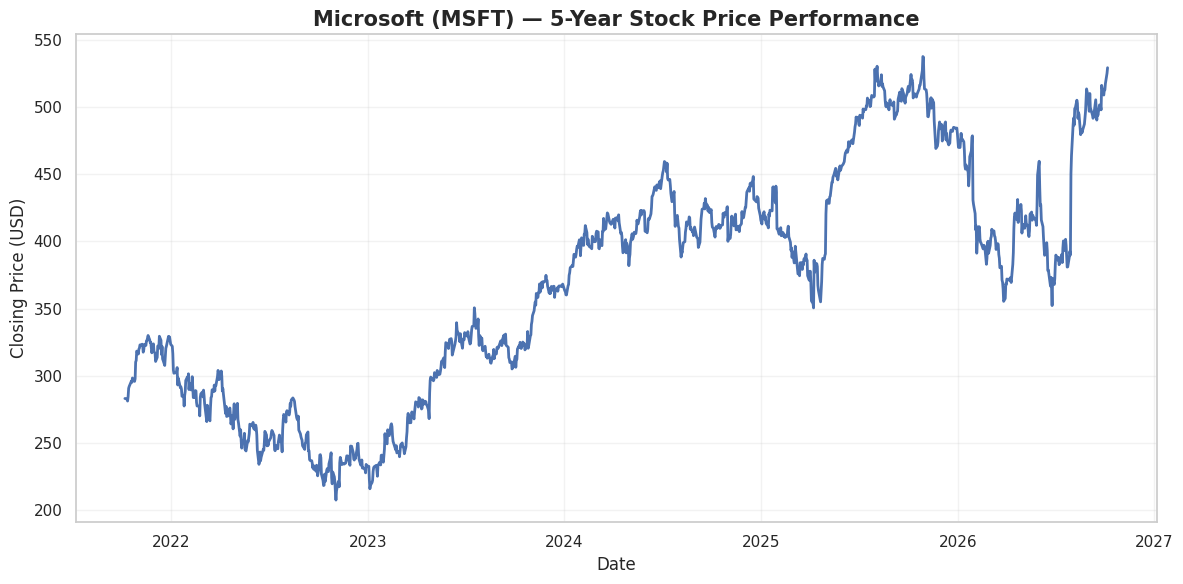

In [126]:
plt.figure(
    figsize=(12, 6)
)

plt.plot(
    prices.index,
    prices["Close"],
    linewidth=2
)

plt.title(
    "Microsoft (MSFT) — 5-Year Stock Price Performance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")

plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

In [127]:
fundamental_trends = financial_summary[
    [
        "Revenue",
        "Revenue Growth %",
        "Operating Income",
        "Operating Margin %",
        "Net Income",
        "Net Profit Margin %",
        "Diluted EPS",
        "Diluted EPS Growth %",
        "Operating Cash Flow",
        "Free Cash Flow",
        "Cash",
        "Total Debt",
        "Net Cash Position",
        "Debt to Equity",
        "Current Ratio",
        "ROA %",
        "ROE %"
    ]
].copy()

display(
    fundamental_trends.round(2)
)

,Revenue,Revenue Growth %,Operating Income,Operating Margin %,Net Income,Net Profit Margin %,Diluted EPS,Diluted EPS Growth %,Operating Cash Flow,Free Cash Flow,Cash,Total Debt,Net Cash Position,Debt to Equity,Current Ratio,ROA %,ROE %
Fiscal Year,,,,,,,,,,,,,,,,,
2023-06-30,"211,915,000,000.00",NaN,"88,523,000,000.00",41.77,"72,361,000,000.00",34.15,9.68,NaN,"87,582,000,000.00","59,475,000,000.00","111,256,000,000.00","59,965,000,000.00","51,291,000,000.00",0.29,1.77,NaN,NaN
2024-06-30,"245,122,000,000.00",15.67,"109,433,000,000.00",44.64,"88,136,000,000.00",35.96,11.80,21.90,"118,548,000,000.00","74,071,000,000.00","75,531,000,000.00","67,127,000,000.00","8,404,000,000.00",0.25,1.27,19.07,37.13
2025-06-30,"281,724,000,000.00",14.93,"128,528,000,000.00",45.62,"101,832,000,000.00",36.15,13.64,15.59,"136,162,000,000.00","71,611,000,000.00","94,555,000,000.00","60,588,000,000.00","33,967,000,000.00",0.18,1.35,18.00,33.28
2026-06-30,"331,839,000,000.00",17.79,"155,237,000,000.00",46.78,"133,749,000,000.00",40.31,17.95,31.60,"182,935,000,000.00","66,987,000,000.00","76,651,000,000.00","56,826,000,000.00","19,825,000,000.00",0.13,1.23,19.42,34.04


In [128]:
latest_date = financial_summary.index.max()

latest_financials = (
    financial_summary
    .loc[latest_date]
)

print(
    f"LATEST AVAILABLE FUNDAMENTAL SNAPSHOT — "
    f"{latest_date.date()}"
)

print("=" * 70)

for metric, value in latest_financials.items():

    if pd.notna(value):

        print(
            f"{metric:<30} : "
            f"{value:,.2f}"
        )

LATEST AVAILABLE FUNDAMENTAL SNAPSHOT — 2026-06-30
Revenue                        : 331,839,000,000.00
Gross Profit                   : 225,465,000,000.00
Operating Income               : 155,237,000,000.00
Net Income                     : 133,749,000,000.00
Basic EPS                      : 18.00
Diluted EPS                    : 17.95
Total Assets                   : 758,376,000,000.00
Total Liabilities              : 315,989,000,000.00
Stockholders Equity            : 442,387,000,000.00
Cash                           : 76,651,000,000.00
Total Debt                     : 56,826,000,000.00
Current Assets                 : 207,710,000,000.00
Current Liabilities            : 168,825,000,000.00
Operating Cash Flow            : 182,935,000,000.00
Capital Expenditure            : -115,948,000,000.00
Free Cash Flow                 : 66,987,000,000.00
Revenue Growth %               : 17.79
Gross Margin %                 : 67.94
Operating Margin %             : 46.78
Net Profit Margin %         

In [129]:
# ============================================================
# DATA QUALITY AUDIT
# ============================================================

quality_report = pd.DataFrame({
    "Metric": financial_summary.columns,
    "Available Values": [
        financial_summary[col].notna().sum()
        for col in financial_summary.columns
    ],
    "Missing Values": [
        financial_summary[col].isna().sum()
        for col in financial_summary.columns
    ]
})

quality_report["Coverage %"] = (
    quality_report["Available Values"]
    / len(financial_summary)
    * 100
)

quality_report = quality_report.sort_values(
    "Coverage %",
    ascending=False
)

display(
    quality_report.reset_index(drop=True)
)

,Metric,Available Values,Missing Values,Coverage %
0,Revenue,4,0,100.00
1,Gross Profit,4,0,100.00
2,Operating Income,4,0,100.00
3,Net Income,4,0,100.00
4,Basic EPS,4,0,100.00
5,Diluted EPS,4,0,100.00
6,Total Assets,4,0,100.00
7,Total Liabilities,4,0,100.00
8,Stockholders Equity,4,0,100.00
9,Cash,4,0,100.00


In [130]:
# ============================================================
# SAVE STAGE 2 OUTPUTS
# ============================================================

financial_summary.to_csv(
    DATA_DIR / "msft_financial_summary.csv"
)

financial_summary_readable.to_csv(
    DATA_DIR / "msft_financial_summary_readable.csv"
)

fundamental_trends.to_csv(
    DATA_DIR / "msft_fundamental_trends.csv"
)

quality_report.to_csv(
    DATA_DIR / "msft_data_quality_report.csv",
    index=False
)

prices.to_csv(
    DATA_DIR / "msft_price_analysis.csv"
)

print("Stage 2 datasets saved successfully.")
print()

for file in sorted(DATA_DIR.iterdir()):
    print("✓", file.name)

Stage 2 datasets saved successfully.

✓ msft_balance_sheet.csv
✓ msft_cash_flow.csv
✓ msft_company_profile.csv
✓ msft_data_quality_report.csv
✓ msft_financial_chunks.json
✓ msft_financial_knowledge_base.json
✓ msft_financial_summary.csv
✓ msft_financial_summary_readable.csv
✓ msft_fundamental_trends.csv
✓ msft_income_statement.csv
✓ msft_price_analysis.csv
✓ msft_price_history.csv


In [131]:
# ============================================================
# STAGE 2 VALIDATION
# ============================================================

stage2_checks = {
    "Financial summary created":
        not financial_summary.empty,

    "Revenue available":
        "Revenue" in financial_summary.columns
        and financial_summary["Revenue"].notna().any(),

    "Net income available":
        "Net Income" in financial_summary.columns
        and financial_summary["Net Income"].notna().any(),

    "EPS available":
        "Diluted EPS" in financial_summary.columns
        and financial_summary["Diluted EPS"].notna().any(),

    "Balance sheet available":
        "Total Assets" in financial_summary.columns
        and financial_summary["Total Assets"].notna().any(),

    "Debt available":
        "Total Debt" in financial_summary.columns
        and financial_summary["Total Debt"].notna().any(),

    "Operating cash flow available":
        "Operating Cash Flow" in financial_summary.columns
        and financial_summary["Operating Cash Flow"].notna().any(),

    "Free cash flow available":
        "Free Cash Flow" in financial_summary.columns
        and financial_summary["Free Cash Flow"].notna().any(),

    "Historical prices available":
        not prices.empty
}

stage2_validation = pd.DataFrame(
    stage2_checks.items(),
    columns=[
        "Stage 2 Requirement",
        "Passed"
    ]
)

display(stage2_validation)

if all(stage2_checks.values()):

    print(
        "\n✓ STAGE 2 COMPLETE — "
        "Financial data is ready for knowledge-base construction."
    )

else:

    print(
        "\n⚠ Review failed checks before proceeding to RAG."
    )

,Stage 2 Requirement,Passed
0,Financial summary created,True
1,Revenue available,True
2,Net income available,True
3,EPS available,True
4,Balance sheet available,True
5,Debt available,True
6,Operating cash flow available,True
7,Free cash flow available,True
8,Historical prices available,True



✓ STAGE 2 COMPLETE — Financial data is ready for knowledge-base construction.


# Stage 3 — Financial Knowledge Base Construction & Metadata-Aware Chunking

This stage transforms the engineered financial data into structured textual documents suitable for Retrieval-Augmented Generation (RAG).

Rather than storing raw DataFrames directly in the vector database, the financial information is organized into topic-specific documents covering company profile, revenue growth, profitability, earnings, balance sheet strength, liquidity, cash flow, financial ratios, and historical stock performance.

Each document is enriched with metadata such as ticker, company, financial category, source, and document type.

The documents are subsequently divided into semantically meaningful chunks while preserving their metadata. These chunks will later be converted into vector embeddings and stored in FAISS for semantic retrieval.

In [132]:
# ============================================================
# FINANCIAL TEXT FORMATTING UTILITIES
# ============================================================

def format_currency(value):
    """
    Convert a numeric financial value into a human-readable
    USD representation.
    """

    if pd.isna(value):
        return "Not available"

    abs_value = abs(value)

    if abs_value >= 1_000_000_000:
        return f"${value / 1_000_000_000:,.2f} billion"

    elif abs_value >= 1_000_000:
        return f"${value / 1_000_000:,.2f} million"

    elif abs_value >= 1_000:
        return f"${value / 1_000:,.2f} thousand"

    else:
        return f"${value:,.2f}"


def format_percentage(value):
    """Format percentage values."""

    if pd.isna(value):
        return "Not available"

    return f"{value:.2f}%"


def format_ratio(value):
    """Format financial ratios."""

    if pd.isna(value):
        return "Not available"

    return f"{value:.2f}"


def format_number(value):
    """Format general numeric values."""

    if pd.isna(value):
        return "Not available"

    return f"{value:,.2f}"

In [133]:
print("Formatting Test")
print("=" * 50)

print(
    "Revenue:",
    format_currency(245_000_000_000)
)

print(
    "Net Margin:",
    format_percentage(35.42)
)

print(
    "Debt-to-Equity:",
    format_ratio(0.47)
)

print(
    "EPS:",
    format_number(12.34)
)

Formatting Test
Revenue: $245.00 billion
Net Margin: 35.42%
Debt-to-Equity: 0.47
EPS: 12.34


In [134]:
# ============================================================
# KNOWLEDGE DOCUMENT CREATOR
# ============================================================

financial_documents = []


def add_financial_document(
    title,
    content,
    category,
    document_type,
    source="Yahoo Finance"
):
    """
    Add a structured financial document to the knowledge base.
    """

    document = {

        "content": content.strip(),

        "metadata": {
            "ticker": TICKER,
            "company": COMPANY_NAME,
            "title": title,
            "category": category,
            "document_type": document_type,
            "source": source
        }
    }

    financial_documents.append(document)

In [135]:
# ============================================================
# DOCUMENT 1 — COMPANY PROFILE
# ============================================================

company_profile_text = f"""
Company: {COMPANY_NAME}
Ticker: {TICKER}

Sector: {company_info.get('sector', 'Not available')}
Industry: {company_info.get('industry', 'Not available')}
Country: {company_info.get('country', 'Not available')}
Currency: {company_info.get('currency', 'Not available')}

Market Capitalization:
{format_currency(company_info.get('marketCap'))}

Current Stock Price:
{format_currency(company_info.get('currentPrice'))}

52-Week High:
{format_currency(company_info.get('fiftyTwoWeekHigh'))}

52-Week Low:
{format_currency(company_info.get('fiftyTwoWeekLow'))}

Trailing P/E Ratio:
{format_ratio(company_info.get('trailingPE'))}

Forward P/E Ratio:
{format_ratio(company_info.get('forwardPE'))}

Price-to-Book Ratio:
{format_ratio(company_info.get('priceToBook'))}

Trailing EPS:
{format_number(company_info.get('trailingEps'))}

Forward EPS:
{format_number(company_info.get('forwardEps'))}

Business Description:
{company_info.get('longBusinessSummary', 'Not available')}
"""


add_financial_document(
    title="Microsoft Company Profile",
    content=company_profile_text,
    category="company_profile",
    document_type="company_information"
)

In [136]:
def fiscal_year_label(date):
    """
    Convert financial statement date into readable fiscal year.
    """

    try:
        return pd.Timestamp(date).strftime("%Y-%m-%d")

    except Exception:
        return str(date)

In [137]:
# ============================================================
# DOCUMENT 2 — REVENUE & GROWTH
# ============================================================

revenue_lines = [
    f"Revenue Performance Analysis for {COMPANY_NAME} ({TICKER})",
    ""
]

for date, row in financial_summary.iterrows():

    revenue_lines.append(
        f"Fiscal period ending {fiscal_year_label(date)}:"
    )

    revenue_lines.append(
        f"- Revenue: {format_currency(row.get('Revenue'))}"
    )

    revenue_lines.append(
        f"- Revenue Growth: "
        f"{format_percentage(row.get('Revenue Growth %'))}"
    )

    revenue_lines.append("")


revenue_text = "\n".join(revenue_lines)


add_financial_document(
    title="Revenue and Revenue Growth",
    content=revenue_text,
    category="revenue_growth",
    document_type="fundamental_analysis"
)

In [138]:
# ============================================================
# DOCUMENT 3 — PROFITABILITY
# ============================================================

profitability_lines = [
    f"Profitability Analysis for {COMPANY_NAME} ({TICKER})",
    ""
]

for date, row in financial_summary.iterrows():

    profitability_lines.extend([

        f"Fiscal period ending {fiscal_year_label(date)}:",

        f"- Gross Profit: "
        f"{format_currency(row.get('Gross Profit'))}",

        f"- Operating Income: "
        f"{format_currency(row.get('Operating Income'))}",

        f"- Net Income: "
        f"{format_currency(row.get('Net Income'))}",

        f"- Gross Margin: "
        f"{format_percentage(row.get('Gross Margin %'))}",

        f"- Operating Margin: "
        f"{format_percentage(row.get('Operating Margin %'))}",

        f"- Net Profit Margin: "
        f"{format_percentage(row.get('Net Profit Margin %'))}",

        ""
    ])


profitability_text = "\n".join(
    profitability_lines
)


add_financial_document(
    title="Profitability and Margins",
    content=profitability_text,
    category="profitability",
    document_type="fundamental_analysis"
)

In [139]:
# ============================================================
# DOCUMENT 4 — EPS & EARNINGS
# ============================================================

earnings_lines = [
    f"Earnings and EPS Analysis for {COMPANY_NAME} ({TICKER})",
    ""
]

for date, row in financial_summary.iterrows():

    earnings_lines.extend([

        f"Fiscal period ending {fiscal_year_label(date)}:",

        f"- Net Income: "
        f"{format_currency(row.get('Net Income'))}",

        f"- Basic EPS: "
        f"{format_number(row.get('Basic EPS'))}",

        f"- Diluted EPS: "
        f"{format_number(row.get('Diluted EPS'))}",

        f"- Diluted EPS Growth: "
        f"{format_percentage(row.get('Diluted EPS Growth %'))}",

        ""
    ])


earnings_text = "\n".join(
    earnings_lines
)


add_financial_document(
    title="Earnings and EPS",
    content=earnings_text,
    category="earnings",
    document_type="fundamental_analysis"
)

In [140]:
# ============================================================
# DOCUMENT 5 — ASSETS & LIABILITIES
# ============================================================

balance_lines = [
    f"Balance Sheet Analysis for {COMPANY_NAME} ({TICKER})",
    ""
]

for date, row in financial_summary.iterrows():

    balance_lines.extend([

        f"Fiscal period ending {fiscal_year_label(date)}:",

        f"- Total Assets: "
        f"{format_currency(row.get('Total Assets'))}",

        f"- Total Liabilities: "
        f"{format_currency(row.get('Total Liabilities'))}",

        f"- Stockholders Equity: "
        f"{format_currency(row.get('Stockholders Equity'))}",

        ""
    ])


balance_text = "\n".join(
    balance_lines
)


add_financial_document(
    title="Assets Liabilities and Equity",
    content=balance_text,
    category="balance_sheet",
    document_type="fundamental_analysis"
)

In [141]:
# ============================================================
# DOCUMENT 6 — DEBT & LIQUIDITY
# ============================================================

liquidity_lines = [
    f"Debt and Liquidity Analysis for {COMPANY_NAME} ({TICKER})",
    ""
]

for date, row in financial_summary.iterrows():

    liquidity_lines.extend([

        f"Fiscal period ending {fiscal_year_label(date)}:",

        f"- Cash Position: "
        f"{format_currency(row.get('Cash'))}",

        f"- Total Debt: "
        f"{format_currency(row.get('Total Debt'))}",

        f"- Net Cash Position: "
        f"{format_currency(row.get('Net Cash Position'))}",

        f"- Current Assets: "
        f"{format_currency(row.get('Current Assets'))}",

        f"- Current Liabilities: "
        f"{format_currency(row.get('Current Liabilities'))}",

        f"- Current Ratio: "
        f"{format_ratio(row.get('Current Ratio'))}",

        f"- Debt-to-Equity Ratio: "
        f"{format_ratio(row.get('Debt to Equity'))}",

        f"- Debt-to-Assets Ratio: "
        f"{format_ratio(row.get('Debt to Assets'))}",

        ""
    ])


liquidity_text = "\n".join(
    liquidity_lines
)


add_financial_document(
    title="Debt Cash and Liquidity",
    content=liquidity_text,
    category="liquidity",
    document_type="fundamental_analysis"
)

In [142]:
# ============================================================
# DOCUMENT 7 — CASH FLOW
# ============================================================

cashflow_lines = [
    f"Cash Flow Analysis for {COMPANY_NAME} ({TICKER})",
    ""
]

for date, row in financial_summary.iterrows():

    cashflow_lines.extend([

        f"Fiscal period ending {fiscal_year_label(date)}:",

        f"- Operating Cash Flow: "
        f"{format_currency(row.get('Operating Cash Flow'))}",

        f"- Capital Expenditure: "
        f"{format_currency(row.get('Capital Expenditure'))}",

        f"- Free Cash Flow: "
        f"{format_currency(row.get('Free Cash Flow'))}",

        f"- Operating Cash Flow Margin: "
        f"{format_percentage(row.get('OCF Margin %'))}",

        f"- Free Cash Flow Margin: "
        f"{format_percentage(row.get('FCF Margin %'))}",

        f"- Cash Conversion Ratio: "
        f"{format_ratio(row.get('Cash Conversion'))}",

        ""
    ])


cashflow_text = "\n".join(
    cashflow_lines
)


add_financial_document(
    title="Operating and Free Cash Flow",
    content=cashflow_text,
    category="cash_flow",
    document_type="fundamental_analysis"
)

In [143]:
# ============================================================
# DOCUMENT 8 — FINANCIAL RATIOS
# ============================================================

ratio_lines = [
    f"Financial Ratio Analysis for {COMPANY_NAME} ({TICKER})",
    ""
]

for date, row in financial_summary.iterrows():

    ratio_lines.extend([

        f"Fiscal period ending {fiscal_year_label(date)}:",

        f"- Gross Margin: "
        f"{format_percentage(row.get('Gross Margin %'))}",

        f"- Operating Margin: "
        f"{format_percentage(row.get('Operating Margin %'))}",

        f"- Net Profit Margin: "
        f"{format_percentage(row.get('Net Profit Margin %'))}",

        f"- Return on Assets (ROA): "
        f"{format_percentage(row.get('ROA %'))}",

        f"- Return on Equity (ROE): "
        f"{format_percentage(row.get('ROE %'))}",

        f"- Debt-to-Equity: "
        f"{format_ratio(row.get('Debt to Equity'))}",

        f"- Current Ratio: "
        f"{format_ratio(row.get('Current Ratio'))}",

        ""
    ])


ratio_text = "\n".join(
    ratio_lines
)


add_financial_document(
    title="Financial Ratios",
    content=ratio_text,
    category="financial_ratios",
    document_type="fundamental_analysis"
)

In [144]:
# ============================================================
# DOCUMENT 9 — HISTORICAL STOCK PERFORMANCE
# ============================================================

historical_performance_text = f"""
Historical Stock Performance for {COMPANY_NAME} ({TICKER})

Analysis Period:
{prices.index.min().date()} to {prices.index.max().date()}

Period Length:
{years:.2f} years

Starting Closing Price:
{format_currency(start_price)}

Ending Closing Price:
{format_currency(end_price)}

Total Price Return:
{format_percentage(total_return)}

Annualized Price Return:
{format_percentage(annualized_return)}

Annualized Volatility:
{format_percentage(annualized_volatility)}

Maximum Drawdown:
{format_percentage(max_drawdown)}

Important:
The return calculation represents price return and does not assume reinvestment of dividends.
"""


add_financial_document(
    title="Historical Stock Performance",
    content=historical_performance_text,
    category="stock_performance",
    document_type="historical_market_analysis"
)

In [145]:
# ============================================================
# DOCUMENT 10 — LATEST FUNDAMENTAL SNAPSHOT
# ============================================================

latest_snapshot_lines = [

    f"Latest Fundamental Financial Snapshot for "
    f"{COMPANY_NAME} ({TICKER})",

    "",

    f"Latest available fiscal period: "
    f"{fiscal_year_label(latest_date)}",

    ""
]


latest_snapshot_fields = {

    "Revenue": "currency",
    "Revenue Growth %": "percentage",

    "Gross Profit": "currency",

    "Operating Income": "currency",
    "Operating Margin %": "percentage",

    "Net Income": "currency",
    "Net Profit Margin %": "percentage",

    "Diluted EPS": "number",
    "Diluted EPS Growth %": "percentage",

    "Total Assets": "currency",
    "Total Liabilities": "currency",

    "Cash": "currency",
    "Total Debt": "currency",
    "Net Cash Position": "currency",

    "Operating Cash Flow": "currency",
    "Free Cash Flow": "currency",

    "Current Ratio": "ratio",
    "Debt to Equity": "ratio",

    "ROA %": "percentage",
    "ROE %": "percentage"
}


for metric, metric_type in latest_snapshot_fields.items():

    value = latest_financials.get(metric)

    if metric_type == "currency":
        formatted_value = format_currency(value)

    elif metric_type == "percentage":
        formatted_value = format_percentage(value)

    elif metric_type == "ratio":
        formatted_value = format_ratio(value)

    else:
        formatted_value = format_number(value)

    latest_snapshot_lines.append(
        f"- {metric}: {formatted_value}"
    )


latest_snapshot_text = "\n".join(
    latest_snapshot_lines
)


add_financial_document(
    title="Latest Fundamental Snapshot",
    content=latest_snapshot_text,
    category="latest_fundamentals",
    document_type="fundamental_snapshot"
)

In [146]:
print("FINANCIAL KNOWLEDGE BASE")
print("=" * 70)

print(
    f"Total documents created: "
    f"{len(financial_documents)}"
)

print()

for i, document in enumerate(
    financial_documents,
    start=1
):

    print(
        f"{i:02d}. "
        f"{document['metadata']['title']}"
    )

    print(
        f"    Category: "
        f"{document['metadata']['category']}"
    )

    print(
        f"    Characters: "
        f"{len(document['content']):,}"
    )

    print()

FINANCIAL KNOWLEDGE BASE
Total documents created: 10

01. Microsoft Company Profile
    Category: company_profile
    Characters: 2,391

02. Revenue and Revenue Growth
    Category: revenue_growth
    Characters: 412

03. Profitability and Margins
    Category: profitability
    Characters: 892

04. Earnings and EPS
    Category: earnings
    Characters: 593

05. Assets Liabilities and Equity
    Category: balance_sheet
    Characters: 623

06. Debt Cash and Liquidity
    Category: liquidity
    Characters: 1,196

07. Operating and Free Cash Flow
    Category: cash_flow
    Characters: 1,027

08. Financial Ratios
    Category: financial_ratios
    Characters: 963

09. Historical Stock Performance
    Category: stock_performance
    Characters: 420

10. Latest Fundamental Snapshot
    Category: latest_fundamentals
    Characters: 684



In [147]:
sample_document = financial_documents[2]

print("METADATA")
print("=" * 70)

print(
    json.dumps(
        sample_document["metadata"],
        indent=2
    )
)

print("\nCONTENT")
print("=" * 70)

print(
    sample_document["content"]
)

METADATA
{
  "ticker": "MSFT",
  "company": "Microsoft Corporation",
  "title": "Profitability and Margins",
  "category": "profitability",
  "document_type": "fundamental_analysis",
  "source": "Yahoo Finance"
}

CONTENT
Profitability Analysis for Microsoft Corporation (MSFT)

Fiscal period ending 2023-06-30:
- Gross Profit: $146.05 billion
- Operating Income: $88.52 billion
- Net Income: $72.36 billion
- Gross Margin: 68.92%
- Operating Margin: 41.77%
- Net Profit Margin: 34.15%

Fiscal period ending 2024-06-30:
- Gross Profit: $171.01 billion
- Operating Income: $109.43 billion
- Net Income: $88.14 billion
- Gross Margin: 69.76%
- Operating Margin: 44.64%
- Net Profit Margin: 35.96%

Fiscal period ending 2025-06-30:
- Gross Profit: $193.89 billion
- Operating Income: $128.53 billion
- Net Income: $101.83 billion
- Gross Margin: 68.82%
- Operating Margin: 45.62%
- Net Profit Margin: 36.15%

Fiscal period ending 2026-06-30:
- Gross Profit: $225.47 billion
- Operating Income: $155.24 b

In [148]:
# ============================================================
# METADATA-AWARE FINANCIAL TEXT CHUNKER
# ============================================================

def chunk_financial_document(
    document,
    max_chars=1200
):
    """
    Split a financial document into semantically meaningful
    chunks while preserving document metadata.

    Paragraph boundaries are preferred so financial sections
    are less likely to be split arbitrarily.
    """

    content = document["content"].strip()

    metadata = document["metadata"].copy()

    paragraphs = [
        paragraph.strip()
        for paragraph in content.split("\n\n")
        if paragraph.strip()
    ]

    chunks = []

    current_chunk = ""

    for paragraph in paragraphs:

        proposed_chunk = (
            f"{current_chunk}\n\n{paragraph}"
            if current_chunk
            else paragraph
        )

        if (
            len(proposed_chunk) <= max_chars
        ):
            current_chunk = proposed_chunk

        else:

            if current_chunk:

                chunks.append(
                    current_chunk.strip()
                )

            current_chunk = paragraph

    if current_chunk:

        chunks.append(
            current_chunk.strip()
        )

    structured_chunks = []

    total_chunks = len(chunks)

    for chunk_index, chunk_text in enumerate(
        chunks,
        start=1
    ):

        chunk_metadata = metadata.copy()

        chunk_metadata.update({

            "chunk_id":
                f"{TICKER}_"
                f"{metadata['category']}_"
                f"{chunk_index:03d}",

            "chunk_index":
                chunk_index,

            "total_chunks":
                total_chunks
        })

        structured_chunks.append({

            "content": chunk_text,

            "metadata": chunk_metadata
        })

    return structured_chunks

In [149]:
# ============================================================
# CREATE RAG CHUNKS
# ============================================================

financial_chunks = []


for document in financial_documents:

    document_chunks = (
        chunk_financial_document(
            document,
            max_chars=1200
        )
    )

    financial_chunks.extend(
        document_chunks
    )


print(
    f"Original documents : "
    f"{len(financial_documents)}"
)

print(
    f"Generated chunks   : "
    f"{len(financial_chunks)}"
)

Original documents : 10
Generated chunks   : 11


In [150]:
chunk_distribution = (
    pd.DataFrame(
        [
            {
                "Title":
                    chunk["metadata"]["title"],

                "Category":
                    chunk["metadata"]["category"],

                "Chunk ID":
                    chunk["metadata"]["chunk_id"],

                "Characters":
                    len(chunk["content"])
            }

            for chunk in financial_chunks
        ]
    )
)


display(
    chunk_distribution
)

,Title,Category,Chunk ID,Characters
0,Microsoft Company Profile,company_profile,MSFT_company_profile_001,374
1,Microsoft Company Profile,company_profile,MSFT_company_profile_002,2015
2,Revenue and Revenue Growth,revenue_growth,MSFT_revenue_growth_001,412
3,Profitability and Margins,profitability,MSFT_profitability_001,892
4,Earnings and EPS,earnings,MSFT_earnings_001,593
5,Assets Liabilities and Equity,balance_sheet,MSFT_balance_sheet_001,623
6,Debt Cash and Liquidity,liquidity,MSFT_liquidity_001,1196
7,Operating and Free Cash Flow,cash_flow,MSFT_cash_flow_001,1027
8,Financial Ratios,financial_ratios,MSFT_financial_ratios_001,963
9,Historical Stock Performance,stock_performance,MSFT_stock_performance_001,420


In [151]:
category_distribution = (
    chunk_distribution
    .groupby("Category")
    .agg(
        Chunks=("Chunk ID", "count"),
        Average_Characters=("Characters", "mean"),
        Maximum_Characters=("Characters", "max")
    )
    .round(2)
    .sort_values(
        "Chunks",
        ascending=False
    )
)


display(
    category_distribution
)

,Chunks,Average_Characters,Maximum_Characters
Category,,,
company_profile,2,"1,194.50",2015
balance_sheet,1,623.00,623
cash_flow,1,"1,027.00",1027
earnings,1,593.00,593
financial_ratios,1,963.00,963
latest_fundamentals,1,684.00,684
liquidity,1,"1,196.00",1196
profitability,1,892.00,892
revenue_growth,1,412.00,412


In [152]:
for chunk in financial_chunks[:5]:

    print("=" * 80)

    print(
        "CHUNK ID:",
        chunk["metadata"]["chunk_id"]
    )

    print(
        "CATEGORY:",
        chunk["metadata"]["category"]
    )

    print(
        "TITLE:",
        chunk["metadata"]["title"]
    )

    print()

    print(
        chunk["content"]
    )

    print()

CHUNK ID: MSFT_company_profile_001
CATEGORY: company_profile
TITLE: Microsoft Company Profile

Company: Microsoft Corporation
Ticker: MSFT

Sector: Technology
Industry: Software - Infrastructure
Country: United States
Currency: USD

Market Capitalization:
$3,930.34 billion

Current Stock Price:
$529.30

52-Week High:
$553.72

52-Week Low:
$349.20

Trailing P/E Ratio:
29.26

Forward P/E Ratio:
22.35

Price-to-Book Ratio:
8.89

Trailing EPS:
18.09

Forward EPS:
23.68

CHUNK ID: MSFT_company_profile_002
CATEGORY: company_profile
TITLE: Microsoft Company Profile

Business Description:
Microsoft Corporation, a technology company, develops and supports a portfolio of technology solutions for individuals and businesses worldwide. Its products include operating systems, server applications, business solution applications, software development tools, desktop and server management tools, and video games; and devices, such as PCs, tablets, gaming and entertainment consoles, other intelligent devi

In [153]:
# ============================================================
# CREATE EMBEDDING / RETRIEVAL TEXT
# ============================================================

def create_retrieval_text(chunk):
    """
    Combine important metadata with chunk content to improve
    semantic retrieval quality.
    """

    metadata = chunk["metadata"]

    retrieval_text = f"""
Company: {metadata['company']}
Ticker: {metadata['ticker']}
Financial Category: {metadata['category']}
Document: {metadata['title']}

{chunk['content']}
""".strip()

    return retrieval_text

In [154]:
for chunk in financial_chunks:

    chunk["retrieval_text"] = (
        create_retrieval_text(chunk)
    )

In [155]:
print(
    financial_chunks[0][
        "retrieval_text"
    ]
)

Company: Microsoft Corporation
Ticker: MSFT
Financial Category: company_profile
Document: Microsoft Company Profile

Company: Microsoft Corporation
Ticker: MSFT

Sector: Technology
Industry: Software - Infrastructure
Country: United States
Currency: USD

Market Capitalization:
$3,930.34 billion

Current Stock Price:
$529.30

52-Week High:
$553.72

52-Week Low:
$349.20

Trailing P/E Ratio:
29.26

Forward P/E Ratio:
22.35

Price-to-Book Ratio:
8.89

Trailing EPS:
18.09

Forward EPS:
23.68


In [156]:
# ============================================================
# DUPLICATE CHUNK CHECK
# ============================================================

chunk_texts = [
    chunk["retrieval_text"]
    for chunk in financial_chunks
]

unique_chunk_count = len(
    set(chunk_texts)
)

duplicate_count = (
    len(chunk_texts)
    - unique_chunk_count
)

print(
    f"Total chunks     : "
    f"{len(chunk_texts)}"
)

print(
    f"Unique chunks    : "
    f"{unique_chunk_count}"
)

print(
    f"Duplicate chunks : "
    f"{duplicate_count}"
)

Total chunks     : 11
Unique chunks    : 11
Duplicate chunks : 0


In [157]:
required_metadata_fields = [
    "ticker",
    "company",
    "title",
    "category",
    "document_type",
    "source",
    "chunk_id",
    "chunk_index",
    "total_chunks"
]


metadata_validation = []


for chunk in financial_chunks:

    missing_fields = [

        field

        for field in required_metadata_fields

        if field not in chunk["metadata"]
    ]

    metadata_validation.append({

        "Chunk ID":
            chunk["metadata"].get(
                "chunk_id",
                "UNKNOWN"
            ),

        "Valid":
            len(missing_fields) == 0,

        "Missing Fields":
            ", ".join(missing_fields)
            if missing_fields
            else "None"
    })


metadata_validation_df = pd.DataFrame(
    metadata_validation
)


display(
    metadata_validation_df
)

,Chunk ID,Valid,Missing Fields
0,MSFT_company_profile_001,True,None
1,MSFT_company_profile_002,True,None
2,MSFT_revenue_growth_001,True,None
3,MSFT_profitability_001,True,None
4,MSFT_earnings_001,True,None
5,MSFT_balance_sheet_001,True,None
6,MSFT_liquidity_001,True,None
7,MSFT_cash_flow_001,True,None
8,MSFT_financial_ratios_001,True,None
9,MSFT_stock_performance_001,True,None


In [158]:
# ============================================================
# SAVE FINANCIAL KNOWLEDGE BASE
# ============================================================

knowledge_base_path = (
    DATA_DIR
    / "msft_financial_knowledge_base.json"
)


with open(
    knowledge_base_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        financial_documents,
        file,
        indent=2,
        ensure_ascii=False,
        default=str
    )


print(
    "Knowledge base saved:"
)

print(
    knowledge_base_path
)

Knowledge base saved:
/content/data/msft_financial_knowledge_base.json


In [159]:
chunks_path = (
    DATA_DIR
    / "msft_financial_chunks.json"
)


with open(
    chunks_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        financial_chunks,
        file,
        indent=2,
        ensure_ascii=False,
        default=str
    )


print(
    "RAG chunks saved:"
)

print(
    chunks_path
)

RAG chunks saved:
/content/data/msft_financial_chunks.json


In [160]:
# ============================================================
# STAGE 3 VALIDATION
# ============================================================

stage3_checks = {

    "Financial documents created":
        len(financial_documents) >= 10,

    "Documents contain content":
        all(
            len(doc["content"].strip()) > 0
            for doc in financial_documents
        ),

    "Chunks created":
        len(financial_chunks) > 0,

    "Retrieval text created":
        all(
            len(
                chunk.get(
                    "retrieval_text",
                    ""
                ).strip()
            ) > 0

            for chunk in financial_chunks
        ),

    "Metadata complete":
        metadata_validation_df[
            "Valid"
        ].all(),

    "Chunk IDs unique":
        len(
            {
                chunk["metadata"]["chunk_id"]
                for chunk in financial_chunks
            }
        )
        == len(financial_chunks),

    "Chunk text unique":
        duplicate_count == 0,

    "Knowledge base saved":
        knowledge_base_path.exists(),

    "RAG chunks saved":
        chunks_path.exists()
}


stage3_validation = pd.DataFrame(
    stage3_checks.items(),
    columns=[
        "Stage 3 Requirement",
        "Passed"
    ]
)


display(
    stage3_validation
)


if all(stage3_checks.values()):

    print(
        "\n✓ STAGE 3 COMPLETE — "
        "Financial knowledge base and metadata-aware "
        "chunks are ready for embedding generation."
    )

else:

    print(
        "\n⚠ STAGE 3 VALIDATION FAILED — "
        "Review failed checks before generating embeddings."
    )

,Stage 3 Requirement,Passed
0,Financial documents created,True
1,Documents contain content,True
2,Chunks created,True
3,Retrieval text created,True
4,Metadata complete,True
5,Chunk IDs unique,True
6,Chunk text unique,True
7,Knowledge base saved,True
8,RAG chunks saved,True



✓ STAGE 3 COMPLETE — Financial knowledge base and metadata-aware chunks are ready for embedding generation.


# Stage 4 — Embedding Generation and FAISS Vector Database

This stage converts the metadata-enriched financial knowledge chunks into dense numerical vector representations using a Sentence Transformer embedding model.

The embeddings are normalized and stored in a FAISS vector index. Normalized vectors combined with inner-product similarity allow the system to perform cosine-similarity-based semantic retrieval.

The resulting vector database enables natural-language financial questions to retrieve the most semantically relevant Microsoft financial information.

The FAISS index and its corresponding chunk metadata are persisted locally so that the vector knowledge base can be reloaded without regenerating embeddings.

In [161]:
# ============================================================
# STAGE 4 — EMBEDDINGS + FAISS
# ============================================================

import faiss

from sentence_transformers import SentenceTransformer


print("FAISS version:", faiss.__version__)
print("Sentence Transformer library imported successfully.")

FAISS version: 1.15.1
Sentence Transformer library imported successfully.


In [162]:
# ============================================================
# EMBEDDING MODEL CONFIGURATION
# ============================================================

EMBEDDING_MODEL_NAME = (
    "sentence-transformers/all-MiniLM-L6-v2"
)

print("Embedding Model:")
print(EMBEDDING_MODEL_NAME)

Embedding Model:
sentence-transformers/all-MiniLM-L6-v2


In [163]:
# ============================================================
# LOAD EMBEDDING MODEL
# ============================================================

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME
)

embedding_dimension = (
    embedding_model.get_sentence_embedding_dimension()
)

print("Embedding model loaded successfully.")
print(
    f"Embedding dimension: "
    f"{embedding_dimension}"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded successfully.
Embedding dimension: 384


In [164]:
# ============================================================
# PREPARE RETRIEVAL TEXT
# ============================================================

retrieval_texts = [
    chunk["retrieval_text"]
    for chunk in financial_chunks
]


print(
    f"Financial chunks ready for embedding: "
    f"{len(retrieval_texts)}"
)

print("\nSample retrieval text:")
print("=" * 70)

print(
    retrieval_texts[0][:1000]
)

Financial chunks ready for embedding: 11

Sample retrieval text:
Company: Microsoft Corporation
Ticker: MSFT
Financial Category: company_profile
Document: Microsoft Company Profile

Company: Microsoft Corporation
Ticker: MSFT

Sector: Technology
Industry: Software - Infrastructure
Country: United States
Currency: USD

Market Capitalization:
$3,930.34 billion

Current Stock Price:
$529.30

52-Week High:
$553.72

52-Week Low:
$349.20

Trailing P/E Ratio:
29.26

Forward P/E Ratio:
22.35

Price-to-Book Ratio:
8.89

Trailing EPS:
18.09

Forward EPS:
23.68


In [165]:
# ============================================================
# GENERATE VECTOR EMBEDDINGS
# ============================================================

embeddings = embedding_model.encode(
    retrieval_texts,
    convert_to_numpy=True,
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings = embeddings.astype(
    "float32"
)


print("\nEmbeddings generated successfully.")

print(
    f"Embedding matrix shape: "
    f"{embeddings.shape}"
)

print(
    f"Data type: "
    f"{embeddings.dtype}"
)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Embeddings generated successfully.
Embedding matrix shape: (11, 384)
Data type: float32


In [166]:
# ============================================================
# VERIFY EMBEDDING NORMALIZATION
# ============================================================

embedding_norms = np.linalg.norm(
    embeddings,
    axis=1
)


print(
    "Minimum vector norm:",
    embedding_norms.min()
)

print(
    "Maximum vector norm:",
    embedding_norms.max()
)

print(
    "Average vector norm:",
    embedding_norms.mean()
)

Minimum vector norm: 0.99999994
Maximum vector norm: 1.0
Average vector norm: 1.0


In [167]:
# ============================================================
# CREATE FAISS VECTOR INDEX
# ============================================================

vector_dimension = embeddings.shape[1]

faiss_index = faiss.IndexFlatIP(
    vector_dimension
)


print("FAISS index created.")

print(
    f"Vector dimension: "
    f"{vector_dimension}"
)

print(
    f"Vectors currently stored: "
    f"{faiss_index.ntotal}"
)

FAISS index created.
Vector dimension: 384
Vectors currently stored: 0


In [168]:
# ============================================================
# ADD EMBEDDINGS TO FAISS
# ============================================================

faiss_index.add(
    embeddings
)


print(
    f"Vectors stored in FAISS: "
    f"{faiss_index.ntotal}"
)

print(
    f"Financial chunks: "
    f"{len(financial_chunks)}"
)

Vectors stored in FAISS: 11
Financial chunks: 11


In [169]:
# ============================================================
# VECTOR → CHUNK MAPPING
# ============================================================

vector_metadata = []


for vector_id, chunk in enumerate(
    financial_chunks
):

    vector_metadata.append({

        "vector_id":
            vector_id,

        "chunk_id":
            chunk["metadata"]["chunk_id"],

        "title":
            chunk["metadata"]["title"],

        "category":
            chunk["metadata"]["category"],

        "source":
            chunk["metadata"]["source"]
    })


vector_metadata_df = pd.DataFrame(
    vector_metadata
)


display(
    vector_metadata_df
)

,vector_id,chunk_id,title,category,source
0,0,MSFT_company_profile_001,Microsoft Company Profile,company_profile,Yahoo Finance
1,1,MSFT_company_profile_002,Microsoft Company Profile,company_profile,Yahoo Finance
2,2,MSFT_revenue_growth_001,Revenue and Revenue Growth,revenue_growth,Yahoo Finance
3,3,MSFT_profitability_001,Profitability and Margins,profitability,Yahoo Finance
4,4,MSFT_earnings_001,Earnings and EPS,earnings,Yahoo Finance
5,5,MSFT_balance_sheet_001,Assets Liabilities and Equity,balance_sheet,Yahoo Finance
6,6,MSFT_liquidity_001,Debt Cash and Liquidity,liquidity,Yahoo Finance
7,7,MSFT_cash_flow_001,Operating and Free Cash Flow,cash_flow,Yahoo Finance
8,8,MSFT_financial_ratios_001,Financial Ratios,financial_ratios,Yahoo Finance
9,9,MSFT_stock_performance_001,Historical Stock Performance,stock_performance,Yahoo Finance


In [170]:
# ============================================================
# SAVE FAISS INDEX
# ============================================================

FAISS_INDEX_PATH = (
    VECTOR_DIR
    / "msft_financial_index.faiss"
)


faiss.write_index(
    faiss_index,
    str(FAISS_INDEX_PATH)
)


print(
    "FAISS index saved successfully:"
)

print(
    FAISS_INDEX_PATH
)

FAISS index saved successfully:
/content/vector_store/msft_financial_index.faiss


In [171]:
VECTOR_MAPPING_PATH = (
    VECTOR_DIR
    / "msft_vector_mapping.json"
)


vector_mapping = []


for vector_id, chunk in enumerate(
    financial_chunks
):

    vector_mapping.append({

        "vector_id":
            vector_id,

        "content":
            chunk["content"],

        "retrieval_text":
            chunk["retrieval_text"],

        "metadata":
            chunk["metadata"]
    })


with open(
    VECTOR_MAPPING_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        vector_mapping,
        file,
        indent=2,
        ensure_ascii=False,
        default=str
    )


print(
    "Vector mapping saved successfully:"
)

print(
    VECTOR_MAPPING_PATH
)

Vector mapping saved successfully:
/content/vector_store/msft_vector_mapping.json


In [172]:
# ============================================================
# RELOAD VECTOR DATABASE
# ============================================================

loaded_faiss_index = (
    faiss.read_index(
        str(FAISS_INDEX_PATH)
    )
)


with open(
    VECTOR_MAPPING_PATH,
    "r",
    encoding="utf-8"
) as file:

    loaded_vector_mapping = (
        json.load(file)
    )


print("Vector database reloaded successfully.")

print(
    f"FAISS vectors: "
    f"{loaded_faiss_index.ntotal}"
)

print(
    f"Mapped chunks: "
    f"{len(loaded_vector_mapping)}"
)

Vector database reloaded successfully.
FAISS vectors: 11
Mapped chunks: 11


In [173]:
# ============================================================
# SEMANTIC FINANCIAL SEARCH
# ============================================================

def semantic_search(
    query,
    top_k=5,
    index=None,
    mapping=None,
    model=None
):
    """
    Retrieve the most semantically relevant financial chunks
    for a natural-language query.
    """

    if index is None:
        index = loaded_faiss_index

    if mapping is None:
        mapping = loaded_vector_mapping

    if model is None:
        model = embedding_model

    # ----------------------------------------
    # Encode user question
    # ----------------------------------------

    query_embedding = model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    query_embedding = (
        query_embedding.astype("float32")
    )

    # Avoid requesting more results
    # than exist in the index.

    top_k = min(
        top_k,
        index.ntotal
    )

    # ----------------------------------------
    # FAISS similarity search
    # ----------------------------------------

    scores, indices = index.search(
        query_embedding,
        top_k
    )

    results = []

    # ----------------------------------------
    # Build structured retrieval results
    # ----------------------------------------

    for rank, (
        score,
        vector_id
    ) in enumerate(
        zip(
            scores[0],
            indices[0]
        ),
        start=1
    ):

        if vector_id < 0:
            continue

        item = mapping[
            int(vector_id)
        ]

        results.append({

            "rank":
                rank,

            "similarity_score":
                float(score),

            "vector_id":
                int(vector_id),

            "chunk_id":
                item["metadata"]["chunk_id"],

            "title":
                item["metadata"]["title"],

            "category":
                item["metadata"]["category"],

            "source":
                item["metadata"]["source"],

            "content":
                item["content"],

            "metadata":
                item["metadata"]
        })

    return results

In [174]:
def display_search_results(
    query,
    results
):
    """
    Display semantic-search results in a readable format.
    """

    print(
        f"QUERY: {query}"
    )

    print(
        "=" * 90
    )

    for result in results:

        print(
            f"\nRANK {result['rank']}"
        )

        print(
            f"Similarity Score : "
            f"{result['similarity_score']:.4f}"
        )

        print(
            f"Chunk ID         : "
            f"{result['chunk_id']}"
        )

        print(
            f"Category         : "
            f"{result['category']}"
        )

        print(
            f"Document         : "
            f"{result['title']}"
        )

        print(
            f"Source           : "
            f"{result['source']}"
        )

        print(
            "-" * 90
        )

        print(
            result["content"]
        )

        print(
            "=" * 90
        )

In [175]:
query_1 = (
    "How has Microsoft's revenue changed over time?"
)


results_1 = semantic_search(
    query=query_1,
    top_k=3
)


display_search_results(
    query_1,
    results_1
)

QUERY: How has Microsoft's revenue changed over time?

RANK 1
Similarity Score : 0.6387
Chunk ID         : MSFT_revenue_growth_001
Category         : revenue_growth
Document         : Revenue and Revenue Growth
Source           : Yahoo Finance
------------------------------------------------------------------------------------------
Revenue Performance Analysis for Microsoft Corporation (MSFT)

Fiscal period ending 2023-06-30:
- Revenue: $211.91 billion
- Revenue Growth: Not available

Fiscal period ending 2024-06-30:
- Revenue: $245.12 billion
- Revenue Growth: 15.67%

Fiscal period ending 2025-06-30:
- Revenue: $281.72 billion
- Revenue Growth: 14.93%

Fiscal period ending 2026-06-30:
- Revenue: $331.84 billion
- Revenue Growth: 17.79%

RANK 2
Similarity Score : 0.5830
Chunk ID         : MSFT_latest_fundamentals_001
Category         : latest_fundamentals
Document         : Latest Fundamental Snapshot
Source           : Yahoo Finance
---------------------------------------------------

In [176]:
query_2 = (
    "How profitable is Microsoft "
    "and what are its profit margins?"
)


results_2 = semantic_search(
    query=query_2,
    top_k=3
)


display_search_results(
    query_2,
    results_2
)

QUERY: How profitable is Microsoft and what are its profit margins?

RANK 1
Similarity Score : 0.6813
Chunk ID         : MSFT_profitability_001
Category         : profitability
Document         : Profitability and Margins
Source           : Yahoo Finance
------------------------------------------------------------------------------------------
Profitability Analysis for Microsoft Corporation (MSFT)

Fiscal period ending 2023-06-30:
- Gross Profit: $146.05 billion
- Operating Income: $88.52 billion
- Net Income: $72.36 billion
- Gross Margin: 68.92%
- Operating Margin: 41.77%
- Net Profit Margin: 34.15%

Fiscal period ending 2024-06-30:
- Gross Profit: $171.01 billion
- Operating Income: $109.43 billion
- Net Income: $88.14 billion
- Gross Margin: 69.76%
- Operating Margin: 44.64%
- Net Profit Margin: 35.96%

Fiscal period ending 2025-06-30:
- Gross Profit: $193.89 billion
- Operating Income: $128.53 billion
- Net Income: $101.83 billion
- Gross Margin: 68.82%
- Operating Margin: 45.62%

In [177]:
query_3 = (
    "What is Microsoft's debt and cash position?"
)


results_3 = semantic_search(
    query=query_3,
    top_k=3
)


display_search_results(
    query_3,
    results_3
)

QUERY: What is Microsoft's debt and cash position?

RANK 1
Similarity Score : 0.7172
Chunk ID         : MSFT_liquidity_001
Category         : liquidity
Document         : Debt Cash and Liquidity
Source           : Yahoo Finance
------------------------------------------------------------------------------------------
Debt and Liquidity Analysis for Microsoft Corporation (MSFT)

Fiscal period ending 2023-06-30:
- Cash Position: $111.26 billion
- Total Debt: $59.97 billion
- Net Cash Position: $51.29 billion
- Current Assets: $184.26 billion
- Current Liabilities: $104.15 billion
- Current Ratio: 1.77
- Debt-to-Equity Ratio: 0.29
- Debt-to-Assets Ratio: 0.15

Fiscal period ending 2024-06-30:
- Cash Position: $75.53 billion
- Total Debt: $67.13 billion
- Net Cash Position: $8.40 billion
- Current Assets: $159.73 billion
- Current Liabilities: $125.29 billion
- Current Ratio: 1.27
- Debt-to-Equity Ratio: 0.25
- Debt-to-Assets Ratio: 0.13

Fiscal period ending 2025-06-30:
- Cash Position: $

In [178]:
query_4 = (
    "How strong is Microsoft's free cash flow "
    "and operating cash flow?"
)


results_4 = semantic_search(
    query=query_4,
    top_k=3
)


display_search_results(
    query_4,
    results_4
)

QUERY: How strong is Microsoft's free cash flow and operating cash flow?

RANK 1
Similarity Score : 0.6748
Chunk ID         : MSFT_cash_flow_001
Category         : cash_flow
Document         : Operating and Free Cash Flow
Source           : Yahoo Finance
------------------------------------------------------------------------------------------
Cash Flow Analysis for Microsoft Corporation (MSFT)

Fiscal period ending 2023-06-30:
- Operating Cash Flow: $87.58 billion
- Capital Expenditure: $-28.11 billion
- Free Cash Flow: $59.48 billion
- Operating Cash Flow Margin: 41.33%
- Free Cash Flow Margin: 28.07%
- Cash Conversion Ratio: 1.21

Fiscal period ending 2024-06-30:
- Operating Cash Flow: $118.55 billion
- Capital Expenditure: $-44.48 billion
- Free Cash Flow: $74.07 billion
- Operating Cash Flow Margin: 48.36%
- Free Cash Flow Margin: 30.22%
- Cash Conversion Ratio: 1.35

Fiscal period ending 2025-06-30:
- Operating Cash Flow: $136.16 billion
- Capital Expenditure: $-64.55 billion
- F

In [179]:
query_5 = (
    "How has Microsoft's stock performed "
    "over the last five years?"
)


results_5 = semantic_search(
    query=query_5,
    top_k=3
)


display_search_results(
    query_5,
    results_5
)

QUERY: How has Microsoft's stock performed over the last five years?

RANK 1
Similarity Score : 0.6554
Chunk ID         : MSFT_stock_performance_001
Category         : stock_performance
Document         : Historical Stock Performance
Source           : Yahoo Finance
------------------------------------------------------------------------------------------
Historical Stock Performance for Microsoft Corporation (MSFT)

Analysis Period:
2021-10-07 to 2026-10-06

Period Length:
5.00 years

Starting Closing Price:
$282.98

Ending Closing Price:
$529.30

Total Price Return:
87.05%

Annualized Price Return:
13.35%

Annualized Volatility:
28.17%

Maximum Drawdown:
-37.15%

Important:
The return calculation represents price return and does not assume reinvestment of dividends.

RANK 2
Similarity Score : 0.6474
Chunk ID         : MSFT_latest_fundamentals_001
Category         : latest_fundamentals
Document         : Latest Fundamental Snapshot
Source           : Yahoo Finance
--------------------

In [180]:
# ============================================================
# RETRIEVAL QUALITY TESTS
# ============================================================

retrieval_tests = [

    {
        "question":
            "How has Microsoft's revenue changed over time?",

        "expected_category":
            "revenue_growth"
    },

    {
        "question":
            "How profitable is Microsoft?",

        "expected_category":
            "profitability"
    },

    {
        "question":
            "What is Microsoft's debt and cash position?",

        "expected_category":
            "liquidity"
    },

    {
        "question":
            "How strong is Microsoft's free cash flow?",

        "expected_category":
            "cash_flow"
    },

    {
        "question":
            "How has Microsoft's stock performed historically?",

        "expected_category":
            "stock_performance"
    }
]


retrieval_evaluation = []


for test in retrieval_tests:

    results = semantic_search(
        query=test["question"],
        top_k=3
    )

    retrieved_categories = [
        result["category"]
        for result in results
    ]

    passed = (
        test["expected_category"]
        in retrieved_categories
    )

    retrieval_evaluation.append({

        "Question":
            test["question"],

        "Expected Category":
            test["expected_category"],

        "Top Categories":
            ", ".join(
                retrieved_categories
            ),

        "Passed":
            passed
    })


retrieval_evaluation_df = pd.DataFrame(
    retrieval_evaluation
)


display(
    retrieval_evaluation_df
)

,Question,Expected Category,Top Categories,Passed
0,How has Microsoft's revenue changed over time?,revenue_growth,"revenue_growth, latest_fundamentals, earnings",True
1,How profitable is Microsoft?,profitability,"profitability, latest_fundamentals, company_pr...",True
2,What is Microsoft's debt and cash position?,liquidity,"liquidity, latest_fundamentals, financial_ratios",True
3,How strong is Microsoft's free cash flow?,cash_flow,"latest_fundamentals, cash_flow, liquidity",True
4,How has Microsoft's stock performed historically?,stock_performance,"latest_fundamentals, stock_performance, compan...",True


In [181]:
retrieval_accuracy = (
    retrieval_evaluation_df[
        "Passed"
    ].mean()
    * 100
)


print(
    f"Top-3 Retrieval Accuracy: "
    f"{retrieval_accuracy:.2f}%"
)

Top-3 Retrieval Accuracy: 100.00%


In [182]:
def search_results_dataframe(
    query,
    top_k=5
):

    results = semantic_search(
        query=query,
        top_k=top_k
    )

    rows = []

    for result in results:

        rows.append({

            "Rank":
                result["rank"],

            "Similarity":
                round(
                    result[
                        "similarity_score"
                    ],
                    4
                ),

            "Category":
                result["category"],

            "Document":
                result["title"],

            "Chunk ID":
                result["chunk_id"]
        })

    return pd.DataFrame(
        rows
    )

In [183]:
display(
    search_results_dataframe(
        "Is Microsoft generating strong cash flow?",
        top_k=5
    )
)

,Rank,Similarity,Category,Document,Chunk ID
0,1,0.66,latest_fundamentals,Latest Fundamental Snapshot,MSFT_latest_fundamentals_001
1,2,0.61,cash_flow,Operating and Free Cash Flow,MSFT_cash_flow_001
2,3,0.58,liquidity,Debt Cash and Liquidity,MSFT_liquidity_001
3,4,0.58,profitability,Profitability and Margins,MSFT_profitability_001
4,5,0.54,revenue_growth,Revenue and Revenue Growth,MSFT_revenue_growth_001


In [184]:
# ============================================================
# PERSISTENCE CONSISTENCY TEST
# ============================================================

test_query = (
    "What is Microsoft's revenue growth?"
)


original_results = semantic_search(
    query=test_query,
    top_k=3,
    index=faiss_index,
    mapping=vector_mapping,
    model=embedding_model
)


reloaded_results = semantic_search(
    query=test_query,
    top_k=3,
    index=loaded_faiss_index,
    mapping=loaded_vector_mapping,
    model=embedding_model
)


original_ids = [
    result["chunk_id"]
    for result in original_results
]


reloaded_ids = [
    result["chunk_id"]
    for result in reloaded_results
]


persistence_consistent = (
    original_ids
    == reloaded_ids
)


print(
    "Original retrieval:"
)

print(
    original_ids
)


print(
    "\nReloaded retrieval:"
)

print(
    reloaded_ids
)


print(
    "\nPersistence consistent:",
    persistence_consistent
)

Original retrieval:
['MSFT_revenue_growth_001', 'MSFT_latest_fundamentals_001', 'MSFT_profitability_001']

Reloaded retrieval:
['MSFT_revenue_growth_001', 'MSFT_latest_fundamentals_001', 'MSFT_profitability_001']

Persistence consistent: True


In [185]:
# ============================================================
# STAGE 4 VALIDATION
# ============================================================

stage4_checks = {

    "Embedding model loaded":
        embedding_model is not None,

    "Embedding dimension valid":
        embedding_dimension == 384,

    "Embeddings generated":
        len(embeddings)
        == len(financial_chunks),

    "Embeddings normalized":
        np.allclose(
            embedding_norms,
            1.0,
            atol=1e-4
        ),

    "FAISS index populated":
        faiss_index.ntotal
        == len(financial_chunks),

    "FAISS index saved":
        FAISS_INDEX_PATH.exists(),

    "Vector mapping saved":
        VECTOR_MAPPING_PATH.exists(),

    "Reloaded index valid":
        loaded_faiss_index.ntotal
        == len(loaded_vector_mapping),

    "Semantic search working":
        len(results_1) > 0,

    "Persistence consistent":
        persistence_consistent,

    "Retrieval tests passed":
        retrieval_evaluation_df[
            "Passed"
        ].all()
}


stage4_validation = pd.DataFrame(
    stage4_checks.items(),
    columns=[
        "Stage 4 Requirement",
        "Passed"
    ]
)


display(
    stage4_validation
)


if all(stage4_checks.values()):

    print(
        "\n✓ STAGE 4 COMPLETE — "
        "Embeddings, FAISS vector database and "
        "semantic retrieval engine are operational."
    )

else:

    print(
        "\n⚠ STAGE 4 VALIDATION FAILED — "
        "Review failed checks before Gemini integration."
    )

,Stage 4 Requirement,Passed
0,Embedding model loaded,True
1,Embedding dimension valid,True
2,Embeddings generated,True
3,Embeddings normalized,True
4,FAISS index populated,True
5,FAISS index saved,True
6,Vector mapping saved,True
7,Reloaded index valid,True
8,Semantic search working,True
9,Persistence consistent,True



✓ STAGE 4 COMPLETE — Embeddings, FAISS vector database and semantic retrieval engine are operational.


# Stage 5 — Gemini Integration and Grounded RAG Financial Analyst

This stage integrates Google Gemini with the FAISS semantic retrieval engine.

For every financial question, the system first retrieves the most relevant financial evidence from the vector database. The retrieved evidence is then supplied to Gemini through a strict grounded prompt.

Gemini is instructed to:
- Use only the retrieved financial context.
- Avoid unsupported assumptions or fabricated financial facts.
- Clearly state when the available evidence is insufficient.
- Distinguish financial facts from analytical interpretation.
- Reference the supporting evidence chunks.

This creates an end-to-end Retrieval-Augmented Generation (RAG) financial analysis pipeline.

In [186]:
# ============================================================
# STAGE 5 — GEMINI + GROUNDED RAG
# ============================================================

from dotenv import load_dotenv
from google import genai
from google.genai import types

print("Gemini SDK imported successfully.")

Gemini SDK imported successfully.


In [187]:
# ============================================================
# LOAD GEMINI API KEY FROM GOOGLE COLAB SECRETS
# ============================================================

from google.colab import userdata

GEMINI_API_KEY = userdata.get("Microsoftfinrag")

if not GEMINI_API_KEY:
    raise ValueError(
        "Gemini API key was not found in Colab Secrets."
    )

print("✓ Gemini API key loaded securely from Colab Secrets.")
print("API key value is intentionally hidden.")

✓ Gemini API key loaded securely from Colab Secrets.
API key value is intentionally hidden.


In [193]:
# ============================================================
# GEMINI CONFIGURATION
# ============================================================

GEMINI_MODEL_NAME = "gemini-3.5-flash-lite"

gemini_client = genai.Client(
    api_key=GEMINI_API_KEY
)

print(
    f"Gemini client initialized."
)

print(
    f"Model: {GEMINI_MODEL_NAME}"
)

Gemini client initialized.
Model: gemini-3.5-flash-lite


In [194]:
# ============================================================
# GEMINI CONNECTION TEST — WITH RETRY/TIMEOUT PROTECTION
# ============================================================

import time

GEMINI_CONNECTION_OK = False

MAX_ATTEMPTS = 3

for attempt in range(1, MAX_ATTEMPTS + 1):

    try:

        print(
            f"Connection attempt "
            f"{attempt}/{MAX_ATTEMPTS}..."
        )

        test_response = (
            gemini_client.models.generate_content(
                model=GEMINI_MODEL_NAME,
                contents=(
                    "Reply only with: "
                    "Gemini connection successful."
                )
            )
        )

        print(test_response.text)

        GEMINI_CONNECTION_OK = bool(
            test_response.text
        )

        if GEMINI_CONNECTION_OK:
            print(
                "\n✓ Gemini connection verified."
            )
            break

    except Exception as error:

        print(
            f"Attempt {attempt} failed:"
        )

        print(error)

        if attempt < MAX_ATTEMPTS:

            wait_seconds = 2 ** attempt

            print(
                f"Waiting {wait_seconds} seconds "
                "before retry..."
            )

            time.sleep(wait_seconds)


if not GEMINI_CONNECTION_OK:

    print(
        "\n✗ Gemini connection could not be verified."
    )

    print(
        "Do NOT continue to the RAG generation cells yet."
    )

Connection attempt 1/3...
Gemini connection successful.

✓ Gemini connection verified.


In [195]:
# ============================================================
# RAG CONFIGURATION
# ============================================================

RAG_TOP_K = 5

MIN_RETRIEVAL_SCORE = 0.25

MAX_CONTEXT_CHARS = 9000


print(
    f"Top-K retrieval: "
    f"{RAG_TOP_K}"
)

print(
    f"Minimum retrieval score: "
    f"{MIN_RETRIEVAL_SCORE}"
)

print(
    f"Maximum context characters: "
    f"{MAX_CONTEXT_CHARS:,}"
)

Top-K retrieval: 5
Minimum retrieval score: 0.25
Maximum context characters: 9,000


In [196]:
# ============================================================
# RETRIEVAL FILTER
# ============================================================

def filter_retrieval_results(
    results,
    minimum_score=MIN_RETRIEVAL_SCORE
):
    """
    Keep retrieval results whose similarity score meets
    the configured relevance threshold.
    """

    filtered_results = [

        result

        for result in results

        if result["similarity_score"]
        >= minimum_score
    ]

    return filtered_results

In [197]:
# ============================================================
# BUILD GROUNDED FINANCIAL CONTEXT
# ============================================================

def build_financial_context(
    results,
    max_chars=MAX_CONTEXT_CHARS
):
    """
    Convert retrieved FAISS results into a structured
    evidence block for Gemini.
    """

    context_blocks = []

    current_length = 0

    for result in results:

        evidence_block = f"""
[EVIDENCE {result['rank']}]

Chunk ID: {result['chunk_id']}
Document: {result['title']}
Category: {result['category']}
Source: {result['source']}
Similarity Score: {result['similarity_score']:.4f}

Financial Evidence:
{result['content']}
""".strip()

        proposed_length = (
            current_length
            + len(evidence_block)
        )

        if proposed_length > max_chars:
            break

        context_blocks.append(
            evidence_block
        )

        current_length = proposed_length

    return "\n\n".join(
        context_blocks
    )

In [198]:
context_test_results = semantic_search(
    query=(
        "How profitable is Microsoft?"
    ),
    top_k=RAG_TOP_K
)

context_test_results = (
    filter_retrieval_results(
        context_test_results
    )
)

context_test = (
    build_financial_context(
        context_test_results
    )
)

print(context_test)

[EVIDENCE 1]

Chunk ID: MSFT_profitability_001
Document: Profitability and Margins
Category: profitability
Source: Yahoo Finance
Similarity Score: 0.6253

Financial Evidence:
Profitability Analysis for Microsoft Corporation (MSFT)

Fiscal period ending 2023-06-30:
- Gross Profit: $146.05 billion
- Operating Income: $88.52 billion
- Net Income: $72.36 billion
- Gross Margin: 68.92%
- Operating Margin: 41.77%
- Net Profit Margin: 34.15%

Fiscal period ending 2024-06-30:
- Gross Profit: $171.01 billion
- Operating Income: $109.43 billion
- Net Income: $88.14 billion
- Gross Margin: 69.76%
- Operating Margin: 44.64%
- Net Profit Margin: 35.96%

Fiscal period ending 2025-06-30:
- Gross Profit: $193.89 billion
- Operating Income: $128.53 billion
- Net Income: $101.83 billion
- Gross Margin: 68.82%
- Operating Margin: 45.62%
- Net Profit Margin: 36.15%

Fiscal period ending 2026-06-30:
- Gross Profit: $225.47 billion
- Operating Income: $155.24 billion
- Net Income: $133.75 billion
- Gross Ma

In [199]:
# ============================================================
# GROUNDED FINANCIAL ANALYST INSTRUCTIONS
# ============================================================

FINANCIAL_ANALYST_SYSTEM_INSTRUCTION = """
You are FinRAG Analyst, an AI assistant for fundamental
stock analysis.

You must answer the user's financial question using ONLY
the financial evidence supplied in the prompt.

STRICT RULES:

1. Do not use outside knowledge to supply financial facts.

2. Do not invent, estimate, assume, or fabricate financial
   values that are absent from the supplied evidence.

3. Financial numbers, dates, ratios, growth rates and stock
   performance figures must be supported by the supplied
   evidence.

4. If the supplied evidence is insufficient to answer the
   question, explicitly say:

   "The retrieved financial evidence is insufficient to
   answer this question reliably."

5. Distinguish factual observations from interpretation.

6. When discussing trends, compare only periods actually
   present in the evidence.

7. Do not present investment advice or tell the user to buy,
   sell, or hold the stock.

8. Cite supporting evidence using the provided chunk IDs in
   square brackets, for example:
   [MSFT_profitability_001]

9. Prefer concise, analytical explanations over generic
   financial commentary.

10. If different evidence blocks contain overlapping
    information, do not double-count or treat repeated
    information as separate facts.

Your role is to provide evidence-grounded fundamental
analysis, not speculation.
""".strip()

In [200]:
# ============================================================
# RAG PROMPT BUILDER
# ============================================================

def build_rag_prompt(
    question,
    financial_context
):
    """
    Construct the user prompt containing the question and
    retrieved financial evidence.
    """

    prompt = f"""
USER FINANCIAL QUESTION:

{question}


RETRIEVED FINANCIAL EVIDENCE:

{financial_context}


TASK:

Answer the financial question using only the retrieved
financial evidence above.

Your response should:

- Directly answer the question.
- Use exact financial figures when relevant.
- Explain important trends or relationships.
- Separate factual evidence from interpretation.
- Cite supporting chunk IDs in square brackets.
- State clearly when evidence is insufficient.
""".strip()

    return prompt

In [201]:
prompt_preview = build_rag_prompt(
    question=(
        "How profitable is Microsoft?"
    ),
    financial_context=context_test
)

print(prompt_preview)

USER FINANCIAL QUESTION:

How profitable is Microsoft?


RETRIEVED FINANCIAL EVIDENCE:

[EVIDENCE 1]

Chunk ID: MSFT_profitability_001
Document: Profitability and Margins
Category: profitability
Source: Yahoo Finance
Similarity Score: 0.6253

Financial Evidence:
Profitability Analysis for Microsoft Corporation (MSFT)

Fiscal period ending 2023-06-30:
- Gross Profit: $146.05 billion
- Operating Income: $88.52 billion
- Net Income: $72.36 billion
- Gross Margin: 68.92%
- Operating Margin: 41.77%
- Net Profit Margin: 34.15%

Fiscal period ending 2024-06-30:
- Gross Profit: $171.01 billion
- Operating Income: $109.43 billion
- Net Income: $88.14 billion
- Gross Margin: 69.76%
- Operating Margin: 44.64%
- Net Profit Margin: 35.96%

Fiscal period ending 2025-06-30:
- Gross Profit: $193.89 billion
- Operating Income: $128.53 billion
- Net Income: $101.83 billion
- Gross Margin: 68.82%
- Operating Margin: 45.62%
- Net Profit Margin: 36.15%

Fiscal period ending 2026-06-30:
- Gross Profit: $225

In [202]:
# ============================================================
# GROUNDED GEMINI GENERATION
# ============================================================

def generate_grounded_answer(
    question,
    financial_context
):
    """
    Generate a Gemini answer constrained by retrieved
    financial evidence.
    """

    prompt = build_rag_prompt(
        question=question,
        financial_context=financial_context
    )

    response = (
        gemini_client.models.generate_content(

            model=GEMINI_MODEL_NAME,

            contents=prompt,

            config=types.GenerateContentConfig(

                system_instruction=(
                    FINANCIAL_ANALYST_SYSTEM_INSTRUCTION
                ),

                temperature=0.1
            )
        )
    )

    if not response.text:
        return (
            "Gemini returned no textual response."
        )

    return response.text.strip()

In [203]:
# ============================================================
# END-TO-END RAG FINANCIAL ANALYST
# ============================================================

def ask_financial_analyst(
    question,
    top_k=RAG_TOP_K,
    minimum_score=MIN_RETRIEVAL_SCORE
):
    """
    Complete RAG pipeline:

    Question
        ↓
    Semantic Retrieval
        ↓
    Relevance Filtering
        ↓
    Financial Context
        ↓
    Gemini
        ↓
    Grounded Answer
    """

    # ----------------------------------------
    # Validate question
    # ----------------------------------------

    if not isinstance(question, str):
        raise TypeError(
            "Question must be a string."
        )

    question = question.strip()

    if not question:
        raise ValueError(
            "Question cannot be empty."
        )

    # ----------------------------------------
    # Retrieve evidence
    # ----------------------------------------

    retrieved_results = semantic_search(
        query=question,
        top_k=top_k
    )

    relevant_results = (
        filter_retrieval_results(
            retrieved_results,
            minimum_score=minimum_score
        )
    )

    # ----------------------------------------
    # Retrieval guardrail
    # ----------------------------------------

    if not relevant_results:

        return {

            "question":
                question,

            "answer":
                (
                    "The retrieved financial evidence "
                    "is insufficient to answer this "
                    "question reliably."
                ),

            "retrieved_evidence":
                [],

            "status":
                "insufficient_evidence"
        }

    # ----------------------------------------
    # Build context
    # ----------------------------------------

    financial_context = (
        build_financial_context(
            relevant_results
        )
    )

    # ----------------------------------------
    # Gemini generation
    # ----------------------------------------

    answer = generate_grounded_answer(
        question=question,
        financial_context=financial_context
    )

    return {

        "question":
            question,

        "answer":
            answer,

        "retrieved_evidence":
            relevant_results,

        "status":
            "answered"
    }

In [204]:
# ============================================================
# DISPLAY RAG RESPONSE
# ============================================================

def display_financial_answer(
    rag_result
):
    """
    Display the final financial answer and retrieval evidence.
    """

    print(
        "FINRAG ANALYST"
    )

    print(
        "=" * 90
    )

    print(
        f"\nQUESTION:\n"
        f"{rag_result['question']}"
    )

    print(
        f"\nANSWER:\n"
        f"{rag_result['answer']}"
    )

    print(
        f"\nSTATUS: "
        f"{rag_result['status']}"
    )

    evidence = (
        rag_result[
            "retrieved_evidence"
        ]
    )

    if evidence:

        print(
            "\nRETRIEVED EVIDENCE"
        )

        print(
            "-" * 90
        )

        for result in evidence:

            print(
                f"Rank {result['rank']} | "
                f"Score "
                f"{result['similarity_score']:.4f} | "
                f"{result['chunk_id']} | "
                f"{result['title']}"
            )

In [205]:
question_1 = (
    "How has Microsoft's revenue changed over time?"
)


rag_result_1 = (
    ask_financial_analyst(
        question_1
    )
)


display_financial_answer(
    rag_result_1
)

FINRAG ANALYST

QUESTION:
How has Microsoft's revenue changed over time?

ANSWER:
Based on the provided financial evidence, Microsoft's revenue has increased across each fiscal period from 2023 through 2026 [MSFT_revenue_growth_001].

### Factual Observations
* **Fiscal period ending 2023-06-30:** Revenue was $211.91 billion (revenue growth is not available for this period) [MSFT_revenue_growth_001].
* **Fiscal period ending 2024-06-30:** Revenue increased to $245.12 billion, representing a revenue growth rate of 15.67% [MSFT_revenue_growth_001].
* **Fiscal period ending 2025-06-30:** Revenue increased to $281.72 billion, representing a revenue growth rate of 14.93% [MSFT_revenue_growth_001].
* **Fiscal period ending 2026-06-30:** Revenue increased to $331.84 billion, representing a revenue growth rate of 17.79% [MSFT_revenue_growth_001].

### Interpretation
* **Trend Analysis:** Microsoft experienced continuous upward momentum in total annual revenue over the four-year span from 2023 

In [206]:
question_2 = (
    "How profitable is Microsoft? "
    "Analyze its operating margin, net profit margin "
    "and profitability trend."
)


rag_result_2 = (
    ask_financial_analyst(
        question_2
    )
)


display_financial_answer(
    rag_result_2
)

FINRAG ANALYST

QUESTION:
How profitable is Microsoft? Analyze its operating margin, net profit margin and profitability trend.

ANSWER:
Based on the retrieved financial evidence, here is an analysis of Microsoft's profitability, operating margin, net profit margin, and its overall profitability trend.

### **Factual Observations**

**Operating Margin:**
* **2023-06-30:** 41.77% [MSFT_profitability_001]
* **2024-06-30:** 44.64% [MSFT_profitability_001]
* **2025-06-30:** 45.62% [MSFT_profitability_001]
* **2026-06-30:** 46.78% [MSFT_profitability_001]

**Net Profit Margin:**
* **2023-06-30:** 34.15% [MSFT_profitability_001]
* **2024-06-30:** 35.96% [MSFT_profitability_001]
* **2025-06-30:** 36.15% [MSFT_profitability_001]
* **2026-06-30:** 40.31% [MSFT_profitability_001]

**Overall Profitability and Income Figures:**
* For the fiscal period ending 2023-06-30, Microsoft reported a Gross Profit of $146.05 billion, Operating Income of $88.52 billion, and Net Income of $72.36 billion [MSFT_

In [207]:
question_3 = (
    "How have Microsoft's net income and "
    "diluted EPS changed over the available "
    "fiscal periods?"
)


rag_result_3 = (
    ask_financial_analyst(
        question_3
    )
)


display_financial_answer(
    rag_result_3
)

FINRAG ANALYST

QUESTION:
How have Microsoft's net income and diluted EPS changed over the available fiscal periods?

ANSWER:
### Factual Observations

Based on the provided evidence, Microsoft's net income and diluted EPS have increased across the available fiscal periods ending June 30, 2023, through June 30, 2026:

* **Fiscal Period Ending 2023-06-30:**
  * Net Income: $72.36 billion [MSFT_earnings_001, MSFT_profitability_001]
  * Diluted EPS: 9.68 (Diluted EPS Growth: Not available) [MSFT_earnings_001]

* **Fiscal Period Ending 2024-06-30:**
  * Net Income: $88.14 billion [MSFT_earnings_001, MSFT_profitability_001]
  * Diluted EPS: 11.80 (Diluted EPS Growth: 21.90%) [MSFT_earnings_001]

* **Fiscal Period Ending 2025-06-30:**
  * Net Income: $101.83 billion [MSFT_earnings_001, MSFT_profitability_001]
  * Diluted EPS: 13.64 (Diluted EPS Growth: 15.59%) [MSFT_earnings_001]

* **Fiscal Period Ending 2026-06-30:**
  * Net Income: $133.75 billion [MSFT_earnings_001, MSFT_profitability_00

In [208]:
question_4 = (
    "Evaluate Microsoft's debt, cash position "
    "and liquidity based on the available "
    "financial evidence."
)


rag_result_4 = (
    ask_financial_analyst(
        question_4
    )
)


display_financial_answer(
    rag_result_4
)

FINRAG ANALYST

QUESTION:
Evaluate Microsoft's debt, cash position and liquidity based on the available financial evidence.

ANSWER:
Based on the supplied financial evidence, here is an evaluation of Microsoft's debt, cash position, and liquidity:

### Factual Observations

**Cash Position:**
* **2023-06-30:** Cash position was $111.26 billion with a net cash position of $51.29 billion [MSFT_liquidity_001].
* **2024-06-30:** Cash position decreased to $75.53 billion, and net cash decreased to $8.40 billion [MSFT_liquidity_001].
* **2025-06-30:** Cash position rose to $94.56 billion, with net cash increasing to $33.97 billion [MSFT_liquidity_001].
* **2026-06-30:** Cash position was $76.65 billion, with a net cash position of $19.82 billion [MSFT_liquidity_001, MSFT_latest_fundamentals_001].

**Total Debt and Leverage Ratios:**
* **Total Debt:** 
  * 2023-06-30: $59.97 billion [MSFT_liquidity_001]
  * 2024-06-30: $67.13 billion [MSFT_liquidity_001]
  * 2025-06-30: $60.59 billion [MSFT_l

In [209]:
question_5 = (
    "How strong is Microsoft's operating cash flow "
    "and free cash flow?"
)


rag_result_5 = (
    ask_financial_analyst(
        question_5
    )
)


display_financial_answer(
    rag_result_5
)

FINRAG ANALYST

QUESTION:
How strong is Microsoft's operating cash flow and free cash flow?

ANSWER:
Based on the provided financial evidence, here is an analysis of Microsoft's operating cash flow and free cash flow:

### Factual Observations
* **Operating Cash Flow (OCF) Trend:** 
  * FY 2023: $87.58 billion (OCF Margin: 41.33%, Cash Conversion Ratio: 1.21) [MSFT_cash_flow_001]
  * FY 2024: $118.55 billion (OCF Margin: 48.36%, Cash Conversion Ratio: 1.35) [MSFT_cash_flow_001]
  * FY 2025: $136.16 billion (OCF Margin: 48.33%, Cash Conversion Ratio: 1.34) [MSFT_cash_flow_001]
  * FY 2026: $182.94 billion (OCF Margin: 55.13%, Cash Conversion Ratio: 1.37) [MSFT_cash_flow_001]
  * Operating cash flow experienced continuous growth across all reported fiscal periods, reaching its peak of $182.94 billion in FY 2026 [MSFT_cash_flow_001].

* **Capital Expenditure (CapEx) Trend:** 
  * FY 2023: $-28.11 billion [MSFT_cash_flow_001]
  * FY 2024: $-44.48 billion [MSFT_cash_flow_001]
  * FY 2025: $

In [210]:
question_6 = (
    "What do Microsoft's profitability, "
    "return on equity, return on assets, "
    "current ratio and debt-to-equity ratio "
    "indicate about its fundamentals?"
)


rag_result_6 = (
    ask_financial_analyst(
        question_6
    )
)


display_financial_answer(
    rag_result_6
)

FINRAG ANALYST

QUESTION:
What do Microsoft's profitability, return on equity, return on assets, current ratio and debt-to-equity ratio indicate about its fundamentals?

ANSWER:
Based on the provided financial evidence, here is an analysis of Microsoft's profitability, return on equity, return on assets, current ratio, and debt-to-equity ratio.

### **Factual Observations**

**1. Profitability (Margins)**
* **Gross Margin:** Stood at 68.92% for 2023, peaked at 69.76% in 2024, slightly decreased to 68.82% in 2025, and registered at 67.94% for the fiscal period ending June 30, 2026 [MSFT_financial_ratios_001].
* **Operating Margin:** Showed a consistent upward trend over the period, moving from 41.77% in 2023 to 44.64% in 2024, 45.62% in 2025, and reaching 46.78% by 2026 [MSFT_financial_ratios_001].
* **Net Profit Margin:** Also exhibited consistent growth year-over-year, rising from 34.15% in 2023, to 35.96% in 2024, 36.15% in 2025, and reaching a high of 40.31% in 2026 [MSFT_financial_

In [211]:
question_7 = (
    "How has Microsoft's stock performed over "
    "the historical period in the knowledge base, "
    "including return, volatility and drawdown?"
)


rag_result_7 = (
    ask_financial_analyst(
        question_7
    )
)


display_financial_answer(
    rag_result_7
)

FINRAG ANALYST

QUESTION:
How has Microsoft's stock performed over the historical period in the knowledge base, including return, volatility and drawdown?

ANSWER:
Based on the supplied financial evidence, Microsoft's stock performance over the historical analysis period (2021-10-07 to 2026-10-06) is characterized by the following factual observations:

* **Starting Closing Price:** $282.98 [MSFT_stock_performance_001]
* **Ending Closing Price:** $529.30 [MSFT_stock_performance_001]
* **Total Price Return:** 87.05% (Note: This calculation represents price return and does not assume the reinvestment of dividends) [MSFT_stock_performance_001]
* **Annualized Price Return:** 13.35% [MSFT_stock_performance_001]
* **Annualized Volatility:** 28.17% [MSFT_stock_performance_001]
* **Maximum Drawdown:** -37.15% [MSFT_stock_performance_001]

**Interpretation:**
Over the 5.00-year historical period, the stock achieved a positive total price return of 87.05% (or an annualized return of 13.35%). Thi

In [212]:
# ============================================================
# EVIDENCE TABLE
# ============================================================

def evidence_dataframe(
    rag_result
):

    rows = []

    for result in rag_result[
        "retrieved_evidence"
    ]:

        rows.append({

            "Rank":
                result["rank"],

            "Similarity":
                round(
                    result[
                        "similarity_score"
                    ],
                    4
                ),

            "Chunk ID":
                result["chunk_id"],

            "Category":
                result["category"],

            "Document":
                result["title"],

            "Source":
                result["source"]
        })

    return pd.DataFrame(rows)

In [213]:
display(
    evidence_dataframe(
        rag_result_5
    )
)

,Rank,Similarity,Chunk ID,Category,Document,Source
0,1,0.68,MSFT_latest_fundamentals_001,latest_fundamentals,Latest Fundamental Snapshot,Yahoo Finance
1,2,0.67,MSFT_cash_flow_001,cash_flow,Operating and Free Cash Flow,Yahoo Finance
2,3,0.59,MSFT_liquidity_001,liquidity,Debt Cash and Liquidity,Yahoo Finance
3,4,0.58,MSFT_profitability_001,profitability,Profitability and Margins,Yahoo Finance
4,5,0.55,MSFT_financial_ratios_001,financial_ratios,Financial Ratios,Yahoo Finance


In [214]:
hallucination_question = (
    "What will Microsoft's exact stock price "
    "be on December 31, 2030?"
)


hallucination_result = (
    ask_financial_analyst(
        hallucination_question
    )
)


display_financial_answer(
    hallucination_result
)

FINRAG ANALYST

QUESTION:
What will Microsoft's exact stock price be on December 31, 2030?

ANSWER:
The retrieved financial evidence is insufficient to answer this question reliably.

STATUS: answered

RETRIEVED EVIDENCE
------------------------------------------------------------------------------------------
Rank 1 | Score 0.6689 | MSFT_company_profile_001 | Microsoft Company Profile
Rank 2 | Score 0.6379 | MSFT_stock_performance_001 | Historical Stock Performance
Rank 3 | Score 0.5378 | MSFT_latest_fundamentals_001 | Latest Fundamental Snapshot
Rank 4 | Score 0.5284 | MSFT_revenue_growth_001 | Revenue and Revenue Growth
Rank 5 | Score 0.5078 | MSFT_earnings_001 | Earnings and EPS


In [215]:
unsupported_question = (
    "What was Microsoft's exact advertising "
    "expense for the latest fiscal year?"
)


unsupported_result = (
    ask_financial_analyst(
        unsupported_question
    )
)


display_financial_answer(
    unsupported_result
)

FINRAG ANALYST

QUESTION:
What was Microsoft's exact advertising expense for the latest fiscal year?

ANSWER:
The retrieved financial evidence is insufficient to answer this question reliably.

STATUS: answered

RETRIEVED EVIDENCE
------------------------------------------------------------------------------------------
Rank 1 | Score 0.5766 | MSFT_revenue_growth_001 | Revenue and Revenue Growth
Rank 2 | Score 0.5527 | MSFT_earnings_001 | Earnings and EPS
Rank 3 | Score 0.5462 | MSFT_latest_fundamentals_001 | Latest Fundamental Snapshot
Rank 4 | Score 0.5351 | MSFT_company_profile_001 | Microsoft Company Profile
Rank 5 | Score 0.5290 | MSFT_stock_performance_001 | Historical Stock Performance


In [216]:
# ============================================================
# INSUFFICIENT-EVIDENCE RESPONSE CHECK
# ============================================================

insufficient_phrases = [

    "insufficient",

    "not provided",

    "not available",

    "cannot determine",

    "cannot be determined",

    "does not contain",

    "not included",

    "unable to determine"
]


unsupported_answer_lower = (
    unsupported_result[
        "answer"
    ].lower()
)


unsupported_guardrail_passed = any(

    phrase
    in unsupported_answer_lower

    for phrase
    in insufficient_phrases
)


print(
    "Unsupported-question guardrail passed:",
    unsupported_guardrail_passed
)

Unsupported-question guardrail passed: True


In [217]:
# ============================================================
# RAG FUNCTIONAL TEST SET
# ============================================================

rag_test_questions = [

    (
        "Revenue",
        "How has Microsoft's revenue changed over time?"
    ),

    (
        "Profitability",
        "How profitable is Microsoft?"
    ),

    (
        "Earnings",
        "How have Microsoft's net income and EPS changed?"
    ),

    (
        "Liquidity",
        "What is Microsoft's debt and cash position?"
    ),

    (
        "Cash Flow",
        "How strong is Microsoft's free cash flow?"
    ),

    (
        "Ratios",
        "What do Microsoft's major financial ratios indicate?"
    ),

    (
        "Stock Performance",
        "How has Microsoft's stock performed historically?"
    )
]

In [218]:
rag_test_results = []


for test_name, question in rag_test_questions:

    print(
        f"Testing: {test_name}"
    )

    try:

        result = (
            ask_financial_analyst(
                question
            )
        )

        rag_test_results.append({

            "Test":
                test_name,

            "Question":
                question,

            "Status":
                result["status"],

            "Evidence Count":
                len(
                    result[
                        "retrieved_evidence"
                    ]
                ),

            "Answer Generated":
                bool(
                    result[
                        "answer"
                    ].strip()
                )
        })

    except Exception as error:

        rag_test_results.append({

            "Test":
                test_name,

            "Question":
                question,

            "Status":
                "error",

            "Evidence Count":
                0,

            "Answer Generated":
                False
        })

        print(
            f"Error: {error}"
        )


rag_test_results_df = pd.DataFrame(
    rag_test_results
)


display(
    rag_test_results_df
)

Testing: Revenue
Testing: Profitability
Testing: Earnings
Testing: Liquidity
Testing: Cash Flow
Testing: Ratios
Testing: Stock Performance


,Test,Question,Status,Evidence Count,Answer Generated
0,Revenue,How has Microsoft's revenue changed over time?,answered,5,True
1,Profitability,How profitable is Microsoft?,answered,5,True
2,Earnings,How have Microsoft's net income and EPS changed?,answered,5,True
3,Liquidity,What is Microsoft's debt and cash position?,answered,5,True
4,Cash Flow,How strong is Microsoft's free cash flow?,answered,5,True
5,Ratios,What do Microsoft's major financial ratios ind...,answered,5,True
6,Stock Performance,How has Microsoft's stock performed historically?,answered,5,True


In [219]:
# ============================================================
# SAVE SAMPLE RAG RESULTS
# ============================================================

sample_rag_outputs = [

    rag_result_1,
    rag_result_2,
    rag_result_3,
    rag_result_4,
    rag_result_5,
    rag_result_6,
    rag_result_7,
    hallucination_result,
    unsupported_result
]


RAG_OUTPUT_PATH = (
    OUTPUT_DIR
    / "msft_rag_sample_outputs.json"
)


with open(
    RAG_OUTPUT_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        sample_rag_outputs,
        file,
        indent=2,
        ensure_ascii=False,
        default=str
    )


print(
    "RAG outputs saved:"
)

print(
    RAG_OUTPUT_PATH
)

RAG outputs saved:
/content/outputs/msft_rag_sample_outputs.json


In [220]:
# ============================================================
# STAGE 5 VALIDATION
# ============================================================

supported_tests_passed = (

    not rag_test_results_df.empty

    and

    (
        rag_test_results_df[
            "Status"
        ]
        != "error"
    ).all()

    and

    rag_test_results_df[
        "Answer Generated"
    ].all()
)


stage5_checks = {

    "Gemini API key loaded":
        bool(GEMINI_API_KEY),

    "Gemini client initialized":
        gemini_client is not None,

    "Gemini connection working":
        GEMINI_CONNECTION_OK,

    "Financial context generated":
        bool(
            context_test.strip()
        ),

    "RAG prompt generated":
        bool(
            prompt_preview.strip()
        ),

    "End-to-end RAG working":
        (
            rag_result_1[
                "status"
            ]
            == "answered"
        ),

    "Evidence returned":
        (
            len(
                rag_result_1[
                    "retrieved_evidence"
                ]
            )
            > 0
        ),

    "Supported financial tests working":
        supported_tests_passed,

    "Unsupported-question guardrail":
        unsupported_guardrail_passed,

    "RAG outputs saved":
        RAG_OUTPUT_PATH.exists()
}


stage5_validation = pd.DataFrame(
    stage5_checks.items(),
    columns=[
        "Stage 5 Requirement",
        "Passed"
    ]
)


display(
    stage5_validation
)


if all(stage5_checks.values()):

    print(
        "\n✓ STAGE 5 COMPLETE — "
        "Gemini is integrated with FAISS and the "
        "grounded RAG financial analyst is operational."
    )

else:

    print(
        "\n⚠ STAGE 5 VALIDATION FAILED — "
        "Review the failed checks before proceeding "
        "to formal RAG evaluation."
    )

,Stage 5 Requirement,Passed
0,Gemini API key loaded,True
1,Gemini client initialized,True
2,Gemini connection working,True
3,Financial context generated,True
4,RAG prompt generated,True
5,End-to-end RAG working,True
6,Evidence returned,True
7,Supported financial tests working,True
8,Unsupported-question guardrail,True
9,RAG outputs saved,True



✓ STAGE 5 COMPLETE — Gemini is integrated with FAISS and the grounded RAG financial analyst is operational.


# Stage 6 — RAG Evaluation, Grounding and Fundamental Analysis

This stage evaluates the FinRAG Analyst at multiple levels rather than relying on a single accuracy score.

The evaluation covers:

1. Retrieval Quality
   - Hit@K
   - Mean Reciprocal Rank (MRR)
   - Retrieval similarity scores

2. Generation and Grounding
   - Answer generation success
   - Evidence citation presence
   - Citation validity
   - Unsupported-question guardrails

3. Financial Analysis Coverage
   - Revenue and growth
   - Profitability
   - Earnings and EPS
   - Assets and liabilities
   - Debt, cash and liquidity
   - Operating and free cash flow
   - Financial ratios
   - Historical stock performance
   - Key financial strengths
   - Key financial risks

The purpose is to demonstrate that the system retrieves relevant financial evidence and produces traceable, evidence-grounded analysis without fabricating unavailable financial information.

In [221]:
# ============================================================
# RETRIEVAL EVALUATION DATASET
# ============================================================

retrieval_eval_dataset = [

    {
        "question":
            "How has Microsoft's revenue changed over time?",
        "expected_categories":
            ["revenue_growth"]
    },

    {
        "question":
            "What is Microsoft's revenue growth trend?",
        "expected_categories":
            ["revenue_growth"]
    },

    {
        "question":
            "How profitable is Microsoft?",
        "expected_categories":
            ["profitability"]
    },

    {
        "question":
            "What are Microsoft's operating and net profit margins?",
        "expected_categories":
            ["profitability", "financial_ratios"]
    },

    {
        "question":
            "How have Microsoft's earnings and EPS changed?",
        "expected_categories":
            ["earnings"]
    },

    {
        "question":
            "What are Microsoft's total assets and liabilities?",
        "expected_categories":
            ["balance_sheet"]
    },

    {
        "question":
            "How much debt and cash does Microsoft have?",
        "expected_categories":
            ["liquidity"]
    },

    {
        "question":
            "How liquid is Microsoft based on its current ratio?",
        "expected_categories":
            ["liquidity", "financial_ratios"]
    },

    {
        "question":
            "How strong is Microsoft's operating cash flow?",
        "expected_categories":
            ["cash_flow"]
    },

    {
        "question":
            "How much free cash flow does Microsoft generate?",
        "expected_categories":
            ["cash_flow"]
    },

    {
        "question":
            "What do Microsoft's ROA and ROE indicate?",
        "expected_categories":
            ["financial_ratios"]
    },

    {
        "question":
            "What is Microsoft's debt-to-equity ratio?",
        "expected_categories":
            ["financial_ratios", "liquidity"]
    },

    {
        "question":
            "How has Microsoft's stock performed historically?",
        "expected_categories":
            ["stock_performance"]
    },

    {
        "question":
            "What were Microsoft's historical return and drawdown?",
        "expected_categories":
            ["stock_performance"]
    },

    {
        "question":
            "Give me Microsoft's latest fundamental snapshot.",
        "expected_categories":
            ["latest_fundamentals"]
    }
]


print(
    "Retrieval evaluation questions:",
    len(retrieval_eval_dataset)
)

Retrieval evaluation questions: 15


In [222]:
# ============================================================
# RETRIEVAL EVALUATION FUNCTION
# ============================================================

def evaluate_retrieval(
    dataset,
    top_k=3
):
    """
    Evaluate retrieval using expected financial categories.

    Metrics collected:
    - Hit@K
    - Reciprocal Rank
    - Rank of first relevant result
    - Top-1 category
    - Top-1 similarity
    """

    evaluation_rows = []

    for item in dataset:

        question = item["question"]

        expected_categories = (
            item["expected_categories"]
        )

        results = semantic_search(
            query=question,
            top_k=top_k
        )

        retrieved_categories = [
            result["category"]
            for result in results
        ]

        relevant_rank = None

        for result in results:

            if (
                result["category"]
                in expected_categories
            ):

                relevant_rank = (
                    result["rank"]
                )

                break

        hit_at_k = (
            relevant_rank is not None
        )

        reciprocal_rank = (
            1 / relevant_rank
            if relevant_rank
            else 0
        )

        top_similarity = (
            results[0]["similarity_score"]
            if results
            else np.nan
        )

        top_category = (
            results[0]["category"]
            if results
            else None
        )

        evaluation_rows.append({

            "Question":
                question,

            "Expected Categories":
                ", ".join(
                    expected_categories
                ),

            "Retrieved Categories":
                ", ".join(
                    retrieved_categories
                ),

            "Relevant Rank":
                relevant_rank,

            f"Hit@{top_k}":
                hit_at_k,

            "Reciprocal Rank":
                reciprocal_rank,

            "Top-1 Category":
                top_category,

            "Top-1 Similarity":
                top_similarity
        })

    return pd.DataFrame(
        evaluation_rows
    )

In [223]:
retrieval_eval_df = evaluate_retrieval(
    retrieval_eval_dataset,
    top_k=3
)


display(
    retrieval_eval_df
)

,Question,Expected Categories,Retrieved Categories,Relevant Rank,Hit@3,Reciprocal Rank,Top-1 Category,Top-1 Similarity
0,How has Microsoft's revenue changed over time?,revenue_growth,"revenue_growth, latest_fundamentals, earnings",1,True,1.00,revenue_growth,0.64
1,What is Microsoft's revenue growth trend?,revenue_growth,"revenue_growth, latest_fundamentals, earnings",1,True,1.00,revenue_growth,0.70
2,How profitable is Microsoft?,profitability,"profitability, latest_fundamentals, company_pr...",1,True,1.00,profitability,0.63
3,What are Microsoft's operating and net profit ...,"profitability, financial_ratios","profitability, latest_fundamentals, financial_...",1,True,1.00,profitability,0.72
4,How have Microsoft's earnings and EPS changed?,earnings,"earnings, latest_fundamentals, revenue_growth",1,True,1.00,earnings,0.65
5,What are Microsoft's total assets and liabilit...,balance_sheet,"balance_sheet, latest_fundamentals, liquidity",1,True,1.00,balance_sheet,0.71
6,How much debt and cash does Microsoft have?,liquidity,"liquidity, latest_fundamentals, cash_flow",1,True,1.00,liquidity,0.65
7,How liquid is Microsoft based on its current r...,"liquidity, financial_ratios","company_profile, liquidity, latest_fundamentals",2,True,0.50,company_profile,0.52
8,How strong is Microsoft's operating cash flow?,cash_flow,"latest_fundamentals, cash_flow, liquidity",2,True,0.50,latest_fundamentals,0.70
9,How much free cash flow does Microsoft generate?,cash_flow,"cash_flow, latest_fundamentals, profitability",1,True,1.00,cash_flow,0.67


In [224]:
# ============================================================
# RETRIEVAL METRICS
# ============================================================

hit_at_3 = (
    retrieval_eval_df[
        "Hit@3"
    ].mean()
)


mrr = (
    retrieval_eval_df[
        "Reciprocal Rank"
    ].mean()
)


top1_accuracy = (

    retrieval_eval_df[
        "Relevant Rank"
    ]
    .eq(1)
    .mean()
)


print(
    f"Hit@3: "
    f"{hit_at_3:.2%}"
)

print(
    f"Top-1 Category Accuracy: "
    f"{top1_accuracy:.2%}"
)

print(
    f"Mean Reciprocal Rank (MRR): "
    f"{mrr:.4f}"
)

Hit@3: 100.00%
Top-1 Category Accuracy: 73.33%
Mean Reciprocal Rank (MRR): 0.8667


In [225]:
# ============================================================
# RETRIEVAL SIMILARITY STATISTICS
# ============================================================

similarity_summary = (

    retrieval_eval_df[
        "Top-1 Similarity"
    ]
    .describe()
)


display(
    similarity_summary
)

,Top-1 Similarity
count,15.00
mean,0.63
std,0.08
min,0.44
25%,0.59
50%,0.65
75%,0.68
max,0.72


In [226]:
retrieval_failures = (

    retrieval_eval_df[
        ~retrieval_eval_df[
            "Hit@3"
        ]
    ]
)


if retrieval_failures.empty:

    print(
        "✓ No Hit@3 retrieval failures detected."
    )

else:

    print(
        "Retrieval failures detected:"
    )

    display(
        retrieval_failures
    )

✓ No Hit@3 retrieval failures detected.


In [227]:
# ============================================================
# CITATION EXTRACTION
# ============================================================

import re


def extract_chunk_citations(
    answer
):
    """
    Extract FinRAG chunk IDs enclosed in square brackets.
    """

    if not answer:
        return []

    citations = re.findall(
        r"\[(MSFT_[A-Za-z0-9_-]+)\]",
        answer
    )

    # Remove duplicates while preserving order.

    return list(
        dict.fromkeys(
            citations
        )
    )

In [228]:
citation_test = (
    "Revenue increased over the available periods "
    "[MSFT_revenue_growth_001]. "
    "Margins remained strong "
    "[MSFT_profitability_001]."
)


print(
    extract_chunk_citations(
        citation_test
    )
)

['MSFT_revenue_growth_001', 'MSFT_profitability_001']


In [229]:
# ============================================================
# CITATION VALIDATION
# ============================================================

def evaluate_citation_grounding(
    rag_result
):
    """
    Check whether citations in a generated answer correspond
    to chunks actually retrieved for that question.
    """

    answer = (
        rag_result.get(
            "answer",
            ""
        )
    )

    cited_chunks = (
        extract_chunk_citations(
            answer
        )
    )

    retrieved_chunks = [

        result["chunk_id"]

        for result in rag_result.get(
            "retrieved_evidence",
            []
        )
    ]

    valid_citations = [

        citation

        for citation in cited_chunks

        if citation
        in retrieved_chunks
    ]

    invalid_citations = [

        citation

        for citation in cited_chunks

        if citation
        not in retrieved_chunks
    ]

    citation_precision = (

        len(valid_citations)
        / len(cited_chunks)

        if cited_chunks
        else 0.0
    )

    return {

        "citation_count":
            len(cited_chunks),

        "valid_citation_count":
            len(valid_citations),

        "invalid_citation_count":
            len(invalid_citations),

        "citation_precision":
            citation_precision,

        "cited_chunks":
            cited_chunks,

        "invalid_citations":
            invalid_citations
    }

In [230]:
# ============================================================
# END-TO-END RAG EVALUATION SET
# ============================================================

generation_eval_questions = [

    {
        "category": "Revenue",
        "question":
            "Analyze Microsoft's revenue and revenue growth."
    },

    {
        "category": "Profitability",
        "question":
            "Analyze Microsoft's profitability and net income."
    },

    {
        "category": "EPS",
        "question":
            "How has Microsoft's diluted EPS changed?"
    },

    {
        "category": "Balance Sheet",
        "question":
            "Analyze Microsoft's assets, liabilities and equity."
    },

    {
        "category": "Debt and Cash",
        "question":
            "Evaluate Microsoft's debt and cash position."
    },

    {
        "category": "Cash Flow",
        "question":
            "Analyze Microsoft's operating cash flow and free cash flow."
    },

    {
        "category": "Ratios",
        "question":
            "Analyze Microsoft's major financial ratios."
    },

    {
        "category": "Historical Performance",
        "question":
            "Analyze Microsoft's historical stock performance."
    }
]


print(
    "Generation evaluation questions:",
    len(generation_eval_questions)
)

Generation evaluation questions: 8


In [231]:
# ============================================================
# END-TO-END GENERATION EVALUATION
# ============================================================

generation_evaluation = []

generation_results = {}


for item in generation_eval_questions:

    category = item["category"]

    question = item["question"]

    print(
        f"Evaluating: {category}"
    )

    try:

        rag_result = (
            ask_financial_analyst(
                question
            )
        )

        generation_results[
            category
        ] = rag_result

        citation_eval = (
            evaluate_citation_grounding(
                rag_result
            )
        )

        generation_evaluation.append({

            "Category":
                category,

            "Status":
                rag_result[
                    "status"
                ],

            "Answer Generated":
                bool(
                    rag_result[
                        "answer"
                    ].strip()
                ),

            "Evidence Count":
                len(
                    rag_result[
                        "retrieved_evidence"
                    ]
                ),

            "Citation Count":
                citation_eval[
                    "citation_count"
                ],

            "Valid Citations":
                citation_eval[
                    "valid_citation_count"
                ],

            "Invalid Citations":
                citation_eval[
                    "invalid_citation_count"
                ],

            "Citation Precision":
                citation_eval[
                    "citation_precision"
                ]
        })

    except Exception as error:

        generation_evaluation.append({

            "Category":
                category,

            "Status":
                "error",

            "Answer Generated":
                False,

            "Evidence Count":
                0,

            "Citation Count":
                0,

            "Valid Citations":
                0,

            "Invalid Citations":
                0,

            "Citation Precision":
                0.0
        })

        print(
            f"Error: {error}"
        )


generation_eval_df = pd.DataFrame(
    generation_evaluation
)


display(
    generation_eval_df
)

Evaluating: Revenue
Evaluating: Profitability
Evaluating: EPS
Evaluating: Balance Sheet
Evaluating: Debt and Cash
Evaluating: Cash Flow
Evaluating: Ratios
Evaluating: Historical Performance


,Category,Status,Answer Generated,Evidence Count,Citation Count,Valid Citations,Invalid Citations,Citation Precision
0,Revenue,answered,True,5,1,1,0,1.00
1,Profitability,answered,True,5,2,2,0,1.00
2,EPS,answered,True,5,1,1,0,1.00
3,Balance Sheet,answered,True,5,2,2,0,1.00
4,Debt and Cash,answered,True,5,2,2,0,1.00
5,Cash Flow,answered,True,5,1,1,0,1.00
6,Ratios,answered,True,5,4,4,0,1.00
7,Historical Performance,answered,True,5,2,2,0,1.00


In [232]:
# ============================================================
# GENERATION METRICS
# ============================================================

answer_generation_rate = (

    generation_eval_df[
        "Answer Generated"
    ].mean()
)


evidence_return_rate = (

    generation_eval_df[
        "Evidence Count"
    ]
    .gt(0)
    .mean()
)


citation_presence_rate = (

    generation_eval_df[
        "Citation Count"
    ]
    .gt(0)
    .mean()
)


total_citations = (
    generation_eval_df[
        "Citation Count"
    ].sum()
)


total_valid_citations = (
    generation_eval_df[
        "Valid Citations"
    ].sum()
)


overall_citation_precision = (

    total_valid_citations
    / total_citations

    if total_citations > 0
    else 0.0
)


print(
    f"Answer Generation Rate: "
    f"{answer_generation_rate:.2%}"
)

print(
    f"Evidence Return Rate: "
    f"{evidence_return_rate:.2%}"
)

print(
    f"Citation Presence Rate: "
    f"{citation_presence_rate:.2%}"
)

print(
    f"Citation Precision: "
    f"{overall_citation_precision:.2%}"
)

Answer Generation Rate: 100.00%
Evidence Return Rate: 100.00%
Citation Presence Rate: 100.00%
Citation Precision: 100.00%


In [233]:
# ============================================================
# UNSUPPORTED QUESTION TEST SET
# ============================================================

unsupported_eval_questions = [

    (
        "What will Microsoft's exact stock price "
        "be on December 31, 2030?"
    ),

    (
        "What was Microsoft's exact advertising "
        "expense in the latest fiscal year?"
    ),

    (
        "How many employees will Microsoft have "
        "exactly five years from now?"
    ),

    (
        "What will Microsoft's exact revenue be "
        "in fiscal year 2035?"
    ),

    (
        "What was Microsoft's exact electricity "
        "expense in the latest fiscal year?"
    )
]


print(
    "Unsupported questions:",
    len(unsupported_eval_questions)
)

Unsupported questions: 5


In [234]:
# ============================================================
# GUARDRAIL DETECTION
# ============================================================

def detects_insufficient_evidence(
    answer
):
    """
    Heuristic check for explicit acknowledgement that the
    retrieved knowledge base cannot support the answer.
    """

    if not answer:
        return False

    answer_lower = (
        answer.lower()
    )

    phrases = [

        "insufficient",

        "not provided",

        "not available",

        "cannot determine",

        "cannot be determined",

        "does not contain",

        "not included",

        "unable to determine",

        "cannot reliably",

        "cannot predict"
    ]

    return any(

        phrase in answer_lower

        for phrase in phrases
    )

In [235]:
# ============================================================
# UNSUPPORTED QUESTION EVALUATION
# ============================================================

guardrail_rows = []

guardrail_results = []


for question in unsupported_eval_questions:

    print(
        f"Testing unsupported question:\n"
        f"{question}\n"
    )

    try:

        result = (
            ask_financial_analyst(
                question
            )
        )

        guardrail_results.append(
            result
        )

        guardrail_passed = (
            detects_insufficient_evidence(
                result["answer"]
            )
        )

        guardrail_rows.append({

            "Question":
                question,

            "Status":
                result["status"],

            "Guardrail Passed":
                guardrail_passed,

            "Evidence Count":
                len(
                    result[
                        "retrieved_evidence"
                    ]
                )
        })

    except Exception as error:

        guardrail_rows.append({

            "Question":
                question,

            "Status":
                "error",

            "Guardrail Passed":
                False,

            "Evidence Count":
                0
        })

        print(error)


guardrail_eval_df = pd.DataFrame(
    guardrail_rows
)


display(
    guardrail_eval_df
)

Testing unsupported question:
What will Microsoft's exact stock price be on December 31, 2030?

Testing unsupported question:
What was Microsoft's exact advertising expense in the latest fiscal year?

Testing unsupported question:
How many employees will Microsoft have exactly five years from now?

Testing unsupported question:
What will Microsoft's exact revenue be in fiscal year 2035?

Testing unsupported question:
What was Microsoft's exact electricity expense in the latest fiscal year?



,Question,Status,Guardrail Passed,Evidence Count
0,What will Microsoft's exact stock price be on ...,answered,True,5
1,What was Microsoft's exact advertising expense...,answered,True,5
2,How many employees will Microsoft have exactly...,answered,True,5
3,What will Microsoft's exact revenue be in fisc...,answered,True,5
4,What was Microsoft's exact electricity expense...,answered,True,5


In [236]:
guardrail_pass_rate = (

    guardrail_eval_df[
        "Guardrail Passed"
    ].mean()
)


print(
    f"Unsupported-Question Guardrail Pass Rate: "
    f"{guardrail_pass_rate:.2%}"
)

Unsupported-Question Guardrail Pass Rate: 100.00%


In [237]:
# ============================================================
# COMPREHENSIVE FUNDAMENTAL ANALYSIS
# ============================================================

comprehensive_question = """
Provide a structured fundamental analysis of Microsoft using
the available financial evidence.

Cover:

1. Revenue and revenue growth
2. Profitability and net income
3. EPS and earnings trend
4. Assets, liabilities and equity
5. Debt, cash position and liquidity
6. Operating cash flow and free cash flow
7. Important financial ratios
8. Historical stock performance

For each section:
- State the important financial evidence.
- Explain the trend.
- Provide a concise interpretation.
- Cite the supporting chunk IDs.

Do not introduce facts that are not contained in the
retrieved evidence.
""".strip()


comprehensive_analysis = (
    ask_financial_analyst(
        comprehensive_question,
        top_k=10,
        minimum_score=0.20
    )
)


display_financial_answer(
    comprehensive_analysis
)

FINRAG ANALYST

QUESTION:
Provide a structured fundamental analysis of Microsoft using
the available financial evidence.

Cover:

1. Revenue and revenue growth
2. Profitability and net income
3. EPS and earnings trend
4. Assets, liabilities and equity
5. Debt, cash position and liquidity
6. Operating cash flow and free cash flow
7. Important financial ratios
8. Historical stock performance

For each section:
- State the important financial evidence.
- Explain the trend.
- Provide a concise interpretation.
- Cite the supporting chunk IDs.

Do not introduce facts that are not contained in the
retrieved evidence.

ANSWER:
Based on the retrieved financial evidence, here is a structured fundamental analysis of Microsoft Corporation.

---

### 1. Revenue and Revenue Growth

* **Financial Evidence:**
  * For the fiscal period ending 2023-06-30, revenue was $211.91 billion (growth not available) [MSFT_revenue_growth_001].
  * For the fiscal period ending 2024-06-30, revenue was $245.12 billion

In [238]:
# ============================================================
# FINANCIAL STRENGTHS
# ============================================================

strengths_question = """
Based only on Microsoft's retrieved financial evidence,
identify its key financial strengths.

Consider areas such as:
- Revenue trend
- Profitability
- Earnings
- Cash generation
- Liquidity
- Debt position
- Returns on assets/equity

For every strength:
1. State the financial evidence.
2. Explain why it may represent a strength.
3. Cite the supporting chunk ID.

Do not make claims that are unsupported by the retrieved
financial evidence.
""".strip()


strengths_analysis = (
    ask_financial_analyst(
        strengths_question,
        top_k=8,
        minimum_score=0.20
    )
)


display_financial_answer(
    strengths_analysis
)

FINRAG ANALYST

QUESTION:
Based only on Microsoft's retrieved financial evidence,
identify its key financial strengths.

Consider areas such as:
- Revenue trend
- Profitability
- Earnings
- Cash generation
- Liquidity
- Debt position
- Returns on assets/equity

For every strength:
1. State the financial evidence.
2. Explain why it may represent a strength.
3. Cite the supporting chunk ID.

Do not make claims that are unsupported by the retrieved
financial evidence.

ANSWER:
Based on the retrieved financial evidence, Microsoft's key financial strengths can be categorized as follows:

### 1. Revenue Growth Trend
* **Financial Evidence:** Microsoft's revenue grew from $211.91 billion for the fiscal period ending 2023-06-30 to $245.12 billion (15.67% growth) in 2024, $281.72 billion (14.93% growth) in 2025, and reached $331.84 billion (17.79% growth) for the fiscal period ending 2026-06-30 [MSFT_revenue_growth_001].
* **Interpretation / Why it is a strength:** This upward trend demonstrate

In [239]:
# ============================================================
# FINANCIAL RISKS
# ============================================================

risks_question = """
Based only on Microsoft's retrieved financial evidence,
identify financial risks, weaknesses, or areas that deserve
investor attention.

Consider only risks that can reasonably be inferred from
the available evidence, such as:
- Slowing growth
- Margin deterioration
- Debt
- Liquidity changes
- Cash-flow weakness
- Earnings volatility
- Historical stock volatility or drawdown

For every risk:
1. State the supporting financial evidence.
2. Explain why it may represent a risk or area to monitor.
3. Cite the supporting chunk ID.

If the retrieved evidence does not support a particular risk,
do not invent one.

Do not provide buy, sell, or hold advice.
""".strip()


risks_analysis = (
    ask_financial_analyst(
        risks_question,
        top_k=8,
        minimum_score=0.20
    )
)


display_financial_answer(
    risks_analysis
)

FINRAG ANALYST

QUESTION:
Based only on Microsoft's retrieved financial evidence,
identify financial risks, weaknesses, or areas that deserve
investor attention.

Consider only risks that can reasonably be inferred from
the available evidence, such as:
- Slowing growth
- Margin deterioration
- Debt
- Liquidity changes
- Cash-flow weakness
- Earnings volatility
- Historical stock volatility or drawdown

For every risk:
1. State the supporting financial evidence.
2. Explain why it may represent a risk or area to monitor.
3. Cite the supporting chunk ID.

If the retrieved evidence does not support a particular risk,
do not invent one.

Do not provide buy, sell, or hold advice.

ANSWER:
Based on the retrieved financial evidence, the following financial risks, weaknesses, or areas deserving investor attention can be identified:

### 1. Gross Margin Compression (2024 to 2026)
*   **Supporting Financial Evidence:** 
    *   For the fiscal period ending 2024-06-30, the Gross Margin was 69.76% 

In [240]:
# ============================================================
# FINAL ANALYSIS CITATION CHECK
# ============================================================

comprehensive_citations = (
    evaluate_citation_grounding(
        comprehensive_analysis
    )
)


strengths_citations = (
    evaluate_citation_grounding(
        strengths_analysis
    )
)


risks_citations = (
    evaluate_citation_grounding(
        risks_analysis
    )
)


final_analysis_citation_df = pd.DataFrame({

    "Analysis": [
        "Comprehensive Fundamentals",
        "Financial Strengths",
        "Financial Risks"
    ],

    "Citation Count": [
        comprehensive_citations[
            "citation_count"
        ],
        strengths_citations[
            "citation_count"
        ],
        risks_citations[
            "citation_count"
        ]
    ],

    "Invalid Citations": [
        comprehensive_citations[
            "invalid_citation_count"
        ],
        strengths_citations[
            "invalid_citation_count"
        ],
        risks_citations[
            "invalid_citation_count"
        ]
    ],

    "Citation Precision": [
        comprehensive_citations[
            "citation_precision"
        ],
        strengths_citations[
            "citation_precision"
        ],
        risks_citations[
            "citation_precision"
        ]
    ]
})


display(
    final_analysis_citation_df
)

,Analysis,Citation Count,Invalid Citations,Citation Precision
0,Comprehensive Fundamentals,10,0,1.00
1,Financial Strengths,7,0,1.00
2,Financial Risks,4,0,1.00


In [241]:
# ============================================================
# RAG EVALUATION SCORECARD
# ============================================================

evaluation_scorecard = pd.DataFrame({

    "Metric": [

        "Retrieval Hit@3",

        "Top-1 Category Accuracy",

        "Mean Reciprocal Rank",

        "Answer Generation Rate",

        "Evidence Return Rate",

        "Citation Presence Rate",

        "Citation Precision",

        "Unsupported Question Guardrail Rate"
    ],

    "Score": [

        hit_at_3,

        top1_accuracy,

        mrr,

        answer_generation_rate,

        evidence_return_rate,

        citation_presence_rate,

        overall_citation_precision,

        guardrail_pass_rate
    ]
})


evaluation_scorecard[
    "Score (%)"
] = (

    evaluation_scorecard[
        "Score"
    ]
    * 100
)


display(
    evaluation_scorecard[
        [
            "Metric",
            "Score (%)"
        ]
    ]
)

,Metric,Score (%)
0,Retrieval Hit@3,100.00
1,Top-1 Category Accuracy,73.33
2,Mean Reciprocal Rank,86.67
3,Answer Generation Rate,100.00
4,Evidence Return Rate,100.00
5,Citation Presence Rate,100.00
6,Citation Precision,100.00
7,Unsupported Question Guardrail Rate,100.00


In [242]:
# ============================================================
# SAVE EVALUATION RESULTS
# ============================================================

retrieval_eval_path = (
    OUTPUT_DIR
    / "msft_retrieval_evaluation.csv"
)

generation_eval_path = (
    OUTPUT_DIR
    / "msft_generation_evaluation.csv"
)

guardrail_eval_path = (
    OUTPUT_DIR
    / "msft_guardrail_evaluation.csv"
)

scorecard_path = (
    OUTPUT_DIR
    / "msft_rag_evaluation_scorecard.csv"
)


retrieval_eval_df.to_csv(
    retrieval_eval_path,
    index=False
)

generation_eval_df.to_csv(
    generation_eval_path,
    index=False
)

guardrail_eval_df.to_csv(
    guardrail_eval_path,
    index=False
)

evaluation_scorecard.to_csv(
    scorecard_path,
    index=False
)


print("Evaluation files saved:")

print(retrieval_eval_path)
print(generation_eval_path)
print(guardrail_eval_path)
print(scorecard_path)

Evaluation files saved:
/content/outputs/msft_retrieval_evaluation.csv
/content/outputs/msft_generation_evaluation.csv
/content/outputs/msft_guardrail_evaluation.csv
/content/outputs/msft_rag_evaluation_scorecard.csv


In [243]:
# ============================================================
# SAVE FINAL FINANCIAL ANALYSES
# ============================================================

final_financial_analysis = {

    "ticker":
        TICKER,

    "company":
        COMPANY_NAME,

    "comprehensive_analysis":
        comprehensive_analysis,

    "financial_strengths":
        strengths_analysis,

    "financial_risks":
        risks_analysis
}


FINAL_ANALYSIS_PATH = (
    OUTPUT_DIR
    / "msft_final_financial_analysis.json"
)


with open(
    FINAL_ANALYSIS_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_financial_analysis,
        file,
        indent=2,
        ensure_ascii=False,
        default=str
    )


print(
    "Final financial analysis saved:"
)

print(
    FINAL_ANALYSIS_PATH
)

Final financial analysis saved:
/content/outputs/msft_final_financial_analysis.json


In [244]:
# ============================================================
# STAGE 6 VALIDATION
# ============================================================

final_citation_validity = (

    final_analysis_citation_df[
        "Invalid Citations"
    ]
    .eq(0)
    .all()
)


stage6_checks = {

    "Retrieval evaluation completed":
        len(retrieval_eval_df)
        == len(retrieval_eval_dataset),

    "Hit@3 calculated":
        not pd.isna(hit_at_3),

    "MRR calculated":
        not pd.isna(mrr),

    "Generation evaluation completed":
        len(generation_eval_df)
        == len(generation_eval_questions),

    "Answers generated successfully":
        answer_generation_rate
        == 1.0,

    "Evidence returned successfully":
        evidence_return_rate
        == 1.0,

    "Generated citations present":
        citation_presence_rate
        == 1.0,

    "Generated citations valid":
        overall_citation_precision
        == 1.0,

    "Unsupported-question guardrails passed":
        guardrail_pass_rate
        == 1.0,

    "Comprehensive analysis generated":
        bool(
            comprehensive_analysis[
                "answer"
            ].strip()
        ),

    "Strengths analysis generated":
        bool(
            strengths_analysis[
                "answer"
            ].strip()
        ),

    "Risks analysis generated":
        bool(
            risks_analysis[
                "answer"
            ].strip()
        ),

    "Final analysis citations valid":
        final_citation_validity,

    "Evaluation scorecard saved":
        scorecard_path.exists(),

    "Final analysis saved":
        FINAL_ANALYSIS_PATH.exists()
}


stage6_validation = pd.DataFrame(
    stage6_checks.items(),
    columns=[
        "Stage 6 Requirement",
        "Passed"
    ]
)


display(
    stage6_validation
)


if all(stage6_checks.values()):

    print(
        "\n✓ STAGE 6 COMPLETE — "
        "RAG evaluation, grounding tests and "
        "fundamental financial analysis are complete."
    )

else:

    print(
        "\n⚠ STAGE 6 VALIDATION REQUIRES REVIEW — "
        "Inspect failed checks before finalizing "
        "the project."
    )

,Stage 6 Requirement,Passed
0,Retrieval evaluation completed,True
1,Hit@3 calculated,True
2,MRR calculated,True
3,Generation evaluation completed,True
4,Answers generated successfully,True
5,Evidence returned successfully,True
6,Generated citations present,True
7,Generated citations valid,True
8,Unsupported-question guardrails passed,True
9,Comprehensive analysis generated,True



✓ STAGE 6 COMPLETE — RAG evaluation, grounding tests and fundamental financial analysis are complete.


# 7. Final Project Documentation

## FinRAG Analyst — AI-Powered Fundamental Stock Analysis Using RAG

### Selected Company
**Microsoft Corporation (NASDAQ: MSFT)**

### Project Objective

The objective of FinRAG Analyst is to build an AI-powered financial analysis system capable of answering natural-language questions about Microsoft using evidence retrieved from structured financial data.

The project combines traditional financial analysis with Retrieval-Augmented Generation (RAG). Financial information is collected from Yahoo Finance, transformed into a structured financial knowledge base, embedded using a Sentence Transformer model, indexed using FAISS, and retrieved according to semantic similarity.

The retrieved financial evidence is supplied to Google Gemini through a grounded prompt that instructs the language model to answer using only the available financial context.

The resulting system functions as an AI Financial Analyst capable of analyzing:

- Revenue and revenue growth
- Profitability and net income
- Earnings per share
- Assets, liabilities and equity
- Debt and cash position
- Liquidity
- Operating cash flow
- Free cash flow
- Financial ratios
- Historical stock performance
- Financial strengths
- Financial risks

The system also includes evidence citations, retrieval evaluation, persistence testing, and hallucination guardrails.

## 7.2 System Architecture

FinRAG Analyst follows an end-to-end Retrieval-Augmented Generation architecture.

```text
                         USER
                           │
                           ▼
                Natural-Language Question
                           │
                           ▼
                 Sentence Transformer
                           │
                           ▼
                    Query Embedding
                           │
                           ▼
                  FAISS Vector Search
                           │
                           ▼
              Top-K Financial Evidence
                           │
                           ▼
                 Relevance Filtering
                           │
                           ▼
              Structured RAG Context
                           │
                           ▼
                Grounded RAG Prompt
                           │
                           ▼
                    Google Gemini
                           │
                           ▼
              Evidence-Grounded Answer
                           │
                    ┌──────┴──────┐
                    ▼             ▼
             Financial Analysis  Chunk IDs


KNOWLEDGE-BASE PIPELINE

                  Yahoo Finance
                       │
        ┌──────────────┼──────────────┐
        ▼              ▼              ▼
 Income Statement  Balance Sheet   Cash Flow
        │              │              │
        └──────────────┼──────────────┘
                       │
             Historical Price Data
                       │
                       ▼
              Financial Engineering
                       │
                       ▼
           Structured Knowledge Base
                       │
                       ▼
            Metadata-Aware Chunking
                       │
                       ▼
           Sentence Transformer Model
                       │
                       ▼
              Normalized Embeddings
                       │
                       ▼
               FAISS Vector Index


---

# Cell 143 — Architecture Explanation

```markdown id="r0z9dn"
### Architecture Components

#### 1. Financial Data Collection
Yahoo Finance is used to obtain Microsoft company information, financial statements, financial metrics, and historical stock-price data.

#### 2. Fundamental Metric Engineering
Raw financial statements are transformed into analytical metrics including revenue growth, profitability margins, EPS growth, leverage ratios, liquidity ratios, return metrics, cash-flow margins, net cash position, and historical stock-performance statistics.

#### 3. Financial Knowledge Base
The structured financial information is converted into topic-specific textual financial documents.

#### 4. Metadata-Aware Chunking
Documents are divided into semantically meaningful chunks. Each chunk contains metadata including ticker, company, category, document title, source, and unique chunk identifier.

#### 5. Embedding Generation
The Sentence Transformer model converts each financial chunk into a dense numerical vector representation.

#### 6. FAISS Vector Database
Normalized embeddings are stored in a FAISS IndexFlatIP index. Because the vectors are normalized, inner-product search is used as cosine-similarity-based retrieval.

#### 7. Semantic Retrieval
A user's question is embedded using the same Sentence Transformer model. FAISS retrieves the most semantically similar financial chunks.

#### 8. Context Construction
Retrieved chunks are converted into structured evidence blocks containing financial data, metadata, similarity scores, sources, and chunk identifiers.

#### 9. Grounded Gemini Generation
The retrieved financial evidence and the user's question are passed to Gemini through a strict grounded prompt.

Gemini is instructed not to invent unavailable financial information and to cite the retrieved chunk identifiers supporting its analysis.

#### 10. Evaluation and Guardrails
The system evaluates retrieval relevance, citation validity, answer generation, evidence availability, and behavior on unsupported financial questions.

## 7.3 Technology Stack

| Component | Technology | Purpose |
|---|---|---|
| Programming Language | Python | Core project implementation |
| Development Environment | Jupyter Notebook | Interactive development and analysis |
| Financial Data | Yahoo Finance / yfinance | Company fundamentals and historical prices |
| Data Processing | pandas | Financial statement transformation and analysis |
| Numerical Computing | NumPy | Financial calculations and vector validation |
| Visualization | Matplotlib / Seaborn | Exploratory financial visualization |
| Embedding Model | sentence-transformers/all-MiniLM-L6-v2 | Semantic text embeddings |
| Vector Database | FAISS | Vector indexing and similarity search |
| Similarity Method | Normalized Inner Product | Cosine-similarity-based retrieval |
| Generative AI | Google Gemini | Evidence-grounded financial analysis |
| Gemini SDK | google-genai | Gemini API integration |
| Configuration | python-dotenv | Secure environment-variable loading |
| Storage | CSV / JSON / FAISS | Financial data, metadata, evaluation and vector persistence |

## 7.4 Financial Metrics and Analytical Coverage

FinRAG Analyst calculates and analyzes multiple dimensions of company fundamentals.

### Growth
- Revenue
- Revenue Growth
- Diluted EPS Growth

### Profitability
- Gross Profit
- Operating Income
- Net Income
- Gross Margin
- Operating Margin
- Net Profit Margin

### Balance Sheet
- Total Assets
- Total Liabilities
- Stockholders' Equity
- Current Assets
- Current Liabilities

### Debt and Liquidity
- Cash and Cash Equivalents
- Total Debt
- Net Cash Position
- Debt-to-Equity Ratio
- Debt-to-Assets Ratio
- Current Ratio

### Returns
- Return on Assets (ROA)
- Return on Equity (ROE)

### Cash Flow
- Operating Cash Flow
- Capital Expenditure
- Free Cash Flow
- Operating Cash Flow Margin
- Free Cash Flow Margin
- Cash Conversion

### Historical Market Performance
- Starting Price
- Ending Price
- Historical Price Return
- Annualized Price Return
- Annualized Volatility
- Maximum Drawdown

Historical return calculations in this project represent price performance and do not assume dividend reinvestment.

## 7.5 Key RAG Design Decisions

### Topic-Specific Financial Documents

Rather than placing the entire financial dataset into one large document, the knowledge base separates financial information into topic-specific documents such as:

- Revenue and Growth
- Profitability
- Earnings and EPS
- Balance Sheet
- Debt, Cash and Liquidity
- Cash Flow
- Financial Ratios
- Historical Stock Performance
- Latest Fundamental Snapshot

This improves semantic retrieval by allowing financial questions to match focused financial concepts.

### Metadata-Aware Chunks

Every financial chunk retains structured metadata including:

- Company
- Ticker
- Financial category
- Document title
- Source
- Chunk ID
- Chunk position

This enables evidence traceability.

### Normalized Vector Retrieval

Document and query embeddings are normalized before FAISS search.

FAISS IndexFlatIP therefore provides exact inner-product search over normalized vectors, which corresponds to cosine-similarity ranking.

### Retrieval Before Generation

Gemini does not independently retrieve the financial data.

Financial evidence is first retrieved from FAISS and explicitly supplied to Gemini.

This creates the core RAG separation:

Question → Retrieval → Evidence → Generation

### Grounding Instructions

Gemini is instructed to:

- Use only retrieved financial evidence for financial facts.
- Avoid fabricating unavailable values.
- State when evidence is insufficient.
- Distinguish factual observations from interpretation.
- Cite supporting financial chunk IDs.
- Avoid unsupported investment recommendations.

## 7.6 Evaluation Methodology

FinRAG Analyst is evaluated at multiple layers.

### Retrieval Evaluation

A manually constructed project evaluation set contains financial questions covering revenue, profitability, earnings, balance-sheet strength, liquidity, cash flow, financial ratios, and historical performance.

The retrieval system is evaluated using:

**Hit@3**

Measures whether at least one expected financial category appears within the top three retrieved chunks.

**Top-1 Category Accuracy**

Measures how often an expected financial category is the highest-ranked retrieved result.

**Mean Reciprocal Rank (MRR)**

Measures how highly the first relevant result is ranked across the evaluation questions.

### Generation Evaluation

The RAG generation pipeline is evaluated using:

- Answer Generation Rate
- Evidence Return Rate
- Citation Presence Rate
- Citation Precision

Citation precision verifies that chunk IDs cited by Gemini were actually present in the retrieved evidence supplied to the model.

### Unsupported-Question Evaluation

Questions that cannot reliably be answered from the financial knowledge base are deliberately submitted to the system.

Examples include exact future stock prices and unavailable expense categories.

The purpose is to test whether the system acknowledges insufficient evidence rather than fabricating unsupported financial facts.

In [246]:
# ============================================================
# FINAL PROJECT EVALUATION RESULTS
# ============================================================

final_metrics = pd.DataFrame({

    "Metric": [
        "Retrieval Hit@3",
        "Top-1 Category Accuracy",
        "Mean Reciprocal Rank",
        "Answer Generation Rate",
        "Evidence Return Rate",
        "Citation Presence Rate",
        "Citation Precision",
        "Unsupported Question Guardrail Rate"
    ],

    "Score (%)": [
        hit_at_3 * 100,
        top1_accuracy * 100,
        mrr * 100,
        answer_generation_rate * 100,
        evidence_return_rate * 100,
        citation_presence_rate * 100,
        overall_citation_precision * 100,
        guardrail_pass_rate * 100
    ]
})


final_metrics["Score (%)"] = (
    final_metrics[
        "Score (%)"
    ].round(2)
)


display(
    final_metrics
)

,Metric,Score (%)
0,Retrieval Hit@3,100.00
1,Top-1 Category Accuracy,73.33
2,Mean Reciprocal Rank,86.67
3,Answer Generation Rate,100.00
4,Evidence Return Rate,100.00
5,Citation Presence Rate,100.00
6,Citation Precision,100.00
7,Unsupported Question Guardrail Rate,100.00


## 7.7 Evaluation Results

The evaluation demonstrates strong performance on the project's defined test set.

### Retrieval Performance

**Hit@3: 100.00%**

Every retrieval evaluation question returned at least one expected financial category within the top three semantic-search results.

This indicates that the vector knowledge base successfully retrieves relevant evidence for the financial question categories represented in the evaluation set.

**Top-1 Category Accuracy: 73.33%**

An expected category was ranked first for approximately three-quarters of the evaluation questions.

The difference between Top-1 accuracy and Hit@3 indicates that the system sometimes ranks a related financial category above the manually designated expected category.

This is reasonable because financial concepts frequently overlap. For example, questions about debt-to-equity may reasonably retrieve both liquidity and financial-ratio documents.

**Mean Reciprocal Rank: 86.67%**

The high MRR indicates that relevant financial evidence generally appears near the top of the retrieval ranking.

### Generation and Grounding Performance

On the defined project evaluation set:

- Answer Generation Rate: 100%
- Evidence Return Rate: 100%
- Citation Presence Rate: 100%
- Citation Precision: 100%
- Unsupported-Question Guardrail Rate: 100%

These results show that all tested supported questions produced answers with retrieved evidence and citations, while cited chunk identifiers corresponded to retrieved chunks.

The unsupported-question tests also successfully triggered insufficient-evidence behavior for all questions in the project's guardrail test set.

These results should not be interpreted as proof that the system is universally 100% accurate. They represent performance on the manually constructed project evaluation set.

## 7.8 Project Assumptions

The project makes the following assumptions:

1. Yahoo Finance provides sufficiently accurate financial information for the educational purpose of this project.

2. Financial statement labels may vary between companies or reporting periods. The project therefore uses alternative candidate labels when extracting important metrics.

3. Annual financial statements are used for fundamental trend analysis.

4. Missing financial values are treated as unavailable rather than automatically estimated.

5. Free cash flow is taken from the available financial data when provided.

6. Financial ratios are calculated from the retrieved financial statements and should be interpreted in the context of the available reporting periods.

7. Sentence-transformer semantic similarity is assumed to provide a useful approximation of relevance between financial questions and financial knowledge chunks.

8. Normalized embedding vectors combined with FAISS inner-product search are used for cosine-similarity-based ranking.

9. Similarity scores are treated as ranking signals, not probabilities or calibrated confidence scores.

10. Historical stock return calculations represent price return. Dividend reinvestment is not incorporated into the historical return calculation.

11. Gemini is used for evidence-grounded interpretation and explanation rather than as the authoritative source of financial numbers.

12. The project is intended for educational fundamental analysis and does not constitute investment advice.

## 7.9 Limitations

### 1. Data-Source Dependency

The project depends on financial information exposed through Yahoo Finance and the yfinance library. Missing, delayed, differently labelled, or unavailable fields can affect downstream analysis.

### 2. Limited Financial History

The available financial statements contain only a limited number of annual reporting periods. Therefore, long-term conclusions should be interpreted cautiously.

### 3. Small Evaluation Dataset

The retrieval and grounding metrics are calculated using a manually constructed project evaluation set. The results demonstrate system behavior on the tested questions but do not establish universal performance.

### 4. Category-Based Retrieval Evaluation

Retrieval relevance is evaluated primarily using expected financial categories. A retrieved chunk may be financially relevant even when its category differs from the manually specified expected category.

This partially explains why Hit@3 can outperform Top-1 category accuracy.

### 5. Similarity Threshold

The retrieval relevance threshold is heuristic and has not been statistically calibrated across a large financial question dataset.

### 6. Broad Multi-Topic Questions

A single semantic query covering many financial topics may not retrieve every relevant category because vector search ranks chunks according to overall semantic similarity.

A more advanced implementation could decompose broad questions into multiple subqueries.

### 7. Citation Validation

Citation precision verifies that cited chunk identifiers were present in the retrieved context.

It does not prove that every sentence generated by the language model is perfectly entailed by the cited evidence.

### 8. LLM Non-Determinism

Although a low generation temperature is used, language-model responses can still vary between executions or model versions.

### 9. No Real-Time Investment Recommendation

The system performs fundamental analysis from the collected knowledge base. It does not incorporate every possible real-time factor such as breaking news, macroeconomic events, analyst revisions, or intraday market conditions.

### 10. Historical Performance Is Not Predictive

Historical stock performance, volatility, and drawdown do not guarantee future performance.

### 11. No Dividend-Reinvested Total Return

Historical performance in this project uses stock-price changes and should not be interpreted as total shareholder return.

### 12. Educational Scope

FinRAG Analyst is an educational analytical system and should not be treated as professional financial or investment advice.

## 7.10 Future Improvements

Several improvements could extend FinRAG Analyst beyond the current capstone scope.

### Multi-Company Analysis
Allow users to dynamically select different publicly traded companies and compare their fundamentals.

### Query Decomposition
Break complex multi-topic financial questions into focused subqueries before retrieval.

### Hybrid Retrieval
Combine semantic vector search with keyword or structured-metric filtering.

### Metadata Filtering
Allow retrieval to explicitly filter by financial category, fiscal period, or document type.

### Reranking
Use a reranking model after FAISS retrieval to improve Top-1 relevance.

### Larger Evaluation Dataset
Create a larger labelled financial QA benchmark covering different question formulations and financial topics.

### Claim-Level Grounding
Evaluate individual generated claims against supporting evidence rather than validating citation identifiers alone.

### Additional Data Sources
Integrate audited regulatory filings or other financial-data providers for broader evidence coverage.

### Comparative Fundamental Analysis
Compare financial growth, profitability, leverage, cash flow, and valuation across multiple companies.

### Interactive User Interface
Deploy the RAG pipeline behind a lightweight web interface where users can enter financial questions and inspect retrieved evidence.

### Automated Knowledge-Base Refresh
Periodically rebuild the financial knowledge base as new financial statements become available.

## 7.11 Conclusion

FinRAG Analyst demonstrates how structured financial data and generative AI can be combined through Retrieval-Augmented Generation to create an evidence-grounded financial analysis system.

The project collects company information, financial statements, financial metrics, and historical stock-price data from Yahoo Finance. Raw financial information is transformed into analytical metrics and topic-specific financial documents before being converted into metadata-aware chunks.

Sentence Transformer embeddings represent these chunks in vector space, while FAISS provides efficient semantic retrieval.

When a user asks a natural-language financial question, the same embedding model converts the question into a query vector. FAISS retrieves relevant financial evidence, and the retrieved context is supplied to Google Gemini through a grounded financial-analysis prompt.

The system therefore separates factual retrieval from natural-language interpretation.

Evaluation on the project's defined test set achieved:

- 100% Retrieval Hit@3
- 73.33% Top-1 Category Accuracy
- 86.67% Mean Reciprocal Rank
- 100% Answer Generation Rate
- 100% Evidence Return Rate
- 100% Citation Presence Rate
- 100% Citation Precision
- 100% Unsupported-Question Guardrail Rate

The results demonstrate that relevant financial evidence was consistently retrieved within the top three results for the tested questions and that the generation pipeline successfully returned evidence-backed answers across the defined evaluation set.

The project also demonstrates an important principle for financial AI applications: large language models are more useful when their analytical capabilities are connected to traceable external evidence rather than relying solely on model knowledge.

FinRAG Analyst therefore fulfills the objective of creating an AI-powered fundamental stock-analysis system in which users can ask natural-language questions and receive structured analysis grounded in a FAISS-powered financial knowledge base.

In [247]:
# ============================================================
# PROJECT ARTIFACT INVENTORY
# ============================================================

project_artifacts = [

    DATA_DIR
    / "msft_income_statement.csv",

    DATA_DIR
    / "msft_balance_sheet.csv",

    DATA_DIR
    / "msft_cash_flow.csv",

    DATA_DIR
    / "msft_price_history.csv",

    DATA_DIR
    / "msft_company_profile.csv",

    DATA_DIR
    / "msft_financial_summary.csv",

    DATA_DIR
    / "msft_financial_summary_readable.csv",

    DATA_DIR
    / "msft_fundamental_trends.csv",

    DATA_DIR
    / "msft_financial_knowledge_base.json",

    DATA_DIR
    / "msft_financial_chunks.json",

    VECTOR_DIR
    / "msft_financial_index.faiss",

    VECTOR_DIR
    / "msft_vector_mapping.json",

    OUTPUT_DIR
    / "msft_rag_sample_outputs.json",

    OUTPUT_DIR
    / "msft_retrieval_evaluation.csv",

    OUTPUT_DIR
    / "msft_generation_evaluation.csv",

    OUTPUT_DIR
    / "msft_guardrail_evaluation.csv",

    OUTPUT_DIR
    / "msft_rag_evaluation_scorecard.csv",

    OUTPUT_DIR
    / "msft_final_financial_analysis.json"
]


artifact_inventory = pd.DataFrame({

    "Artifact": [
        path.name
        for path in project_artifacts
    ],

    "Directory": [
        path.parent.name
        for path in project_artifacts
    ],

    "Exists": [
        path.exists()
        for path in project_artifacts
    ]
})


display(
    artifact_inventory
)

,Artifact,Directory,Exists
0,msft_income_statement.csv,data,True
1,msft_balance_sheet.csv,data,True
2,msft_cash_flow.csv,data,True
3,msft_price_history.csv,data,True
4,msft_company_profile.csv,data,True
5,msft_financial_summary.csv,data,True
6,msft_financial_summary_readable.csv,data,True
7,msft_fundamental_trends.csv,data,True
8,msft_financial_knowledge_base.json,data,True
9,msft_financial_chunks.json,data,True


In [248]:
# ============================================================
# CREATE REQUIREMENTS.TXT
# ============================================================

requirements = """yfinance
pandas
numpy
matplotlib
seaborn
faiss-cpu
sentence-transformers
google-genai
python-dotenv
"""


requirements_path = (
    BASE_DIR
    / "requirements.txt"
)


requirements_path.write_text(
    requirements,
    encoding="utf-8"
)


print(
    "requirements.txt created:"
)

print(
    requirements_path
)

requirements.txt created:
/content/requirements.txt


In [249]:
# ============================================================
# CREATE .gitignore
# ============================================================

gitignore_content = """.env
.env.*
__pycache__/
*.pyc
.ipynb_checkpoints/
.DS_Store
"""


gitignore_path = (
    BASE_DIR
    / ".gitignore"
)


gitignore_path.write_text(
    gitignore_content,
    encoding="utf-8"
)


print(
    ".gitignore created:"
)

print(
    gitignore_path
)

.gitignore created:
/content/.gitignore


In [250]:
# ============================================================
# SECURITY CHECK
# ============================================================

gitignore_text = (
    gitignore_path.read_text(
        encoding="utf-8"
    )
)


env_protected = (
    ".env"
    in gitignore_text
)


api_key_not_empty = (
    bool(
        GEMINI_API_KEY
    )
)


print(
    "API key configured:",
    api_key_not_empty
)

print(
    ".env protected by .gitignore:",
    env_protected
)

print(
    "API key value: [HIDDEN]"
)

API key configured: True
.env protected by .gitignore: True
API key value: [HIDDEN]


## 7.12 Reproducibility

### Setup

1. Clone or download the project repository.

2. Create a Python virtual environment.

3. Install the required dependencies:

```bash
pip install -r requirements.txt

## 7.13 Portfolio Summary

### FinRAG Analyst
**AI-Powered Fundamental Stock Analysis using Retrieval-Augmented Generation**

Built an end-to-end financial RAG system that transforms structured company fundamentals into a searchable vector knowledge base and uses retrieved evidence to generate grounded financial analysis.

### Key Engineering Features

- Automated financial-data collection using Yahoo Finance
- Financial statement normalization and validation
- Fundamental metric engineering
- Topic-specific financial knowledge-base construction
- Metadata-aware semantic chunking
- Sentence Transformer embeddings
- FAISS vector indexing and persistence
- Natural-language semantic retrieval
- Google Gemini integration
- Evidence-grounded prompt engineering
- Chunk-level source traceability
- Unsupported-question guardrails
- Retrieval evaluation using Hit@K and MRR
- Citation validation
- Evidence-grounded strengths and risks analysis

### Evaluation Results

- Retrieval Hit@3: 100%
- Top-1 Category Accuracy: 73.33%
- Mean Reciprocal Rank: 86.67%
- Answer Generation Rate: 100%
- Evidence Return Rate: 100%
- Citation Presence Rate: 100%
- Citation Precision: 100%
- Unsupported-Question Guardrail Rate: 100%

Evaluation results represent performance on the project's manually constructed evaluation set.

In [252]:
# ============================================================
# FINAL PROJECT VALIDATION
# ============================================================

stage7_checks = {

    "Company configured":
        TICKER == "MSFT",

    "Financial data available":
        not financial_summary.empty,

    "Knowledge base created":
        len(financial_documents) > 0,

    "Financial chunks created":
        len(financial_chunks) > 0,

    "Embeddings generated":
        len(embeddings)
        == len(financial_chunks),

    "FAISS index operational":
        faiss_index.ntotal
        == len(financial_chunks),

    "Gemini operational":
        GEMINI_CONNECTION_OK,

    "RAG operational":
        rag_result_1[
            "status"
        ]
        == "answered",

    "Retrieval evaluation complete":
        len(retrieval_eval_df)
        > 0,

    "Generation evaluation complete":
        len(generation_eval_df)
        > 0,

    "Guardrail evaluation complete":
        len(guardrail_eval_df)
        > 0,

    "Comprehensive analysis available":
        bool(
            comprehensive_analysis[
                "answer"
            ].strip()
        ),

    "Strengths analysis available":
        bool(
            strengths_analysis[
                "answer"
            ].strip()
        ),

    "Risks analysis available":
        bool(
            risks_analysis[
                "answer"
            ].strip()
        ),

    "All project artifacts exist":
        artifact_inventory[
            "Exists"
        ].all(),

    "requirements.txt created":
        requirements_path.exists(),

    ".gitignore created":
        gitignore_path.exists(),

    ".env protected":
        env_protected
}


stage7_validation = pd.DataFrame(
    stage7_checks.items(),
    columns=[
        "Final Project Requirement",
        "Passed"
    ]
)


display(
    stage7_validation
)


if all(stage7_checks.values()):

    print(
        "\n✓ FINRAG ANALYST COMPLETE"
    )

    print(
        "All final project validation checks passed."
    )

    print(
        "The notebook is ready for final review "
        "and portfolio packaging."
    )

else:

    print(
        "\n⚠ FINAL PROJECT REVIEW REQUIRED"
    )

    print(
        "Inspect failed validation checks before "
        "submission."
    )

,Final Project Requirement,Passed
0,Company configured,True
1,Financial data available,True
2,Knowledge base created,True
3,Financial chunks created,True
4,Embeddings generated,True
5,FAISS index operational,True
6,Gemini operational,True
7,RAG operational,True
8,Retrieval evaluation complete,True
9,Generation evaluation complete,True



✓ FINRAG ANALYST COMPLETE
All final project validation checks passed.
The notebook is ready for final review and portfolio packaging.
